# Transformer-based Time Series Forecasting
This notebook replaces the LSTM model with a transformer encoder model for forecasting on a dataset containing multiple time series (identified by ID).

In [140]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout, LayerNormalization, GlobalAveragePooling1D, MultiHeadAttention
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback
from keras.optimizers import AdamW
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap
import seaborn as sns


In [141]:
print(tf.__version__)


2.19.0


# INPUTS

In [199]:
dynamic_features = ['pr_rolling30', 'at_rolling30', 'ws_rolling30', 'dp_rolling30',
       'sr_rolling30', 'lr_rolling30', 'twd_rolling30_log']#
#static_features = ['mch_elevation', 'site_enc', 'species_enc', 'year_enc', 'day_cos', 'day_sin']  # static features
static_features = ['mch_elevation',  'site_longitude', 'site_latitude', 'species_enc', 'year_enc', 'day_cos', 'day_sin'] 
features = dynamic_features
target_column = "twd_rolling30_log"

features_to_scale = [
    'pr_rolling30', 'at_rolling30', 'ws_rolling30',
    'dp_rolling30', 'sr_rolling30', 'lr_rolling30',
    'day_cos', 'day_sin',
    'mch_elevation', 'site_longitude', 'site_latitude',
    target_column  # target
]

SEQ_LEN = 60 # number of past time steps the model uses to make each prediction.
forec_horizon = 1  # number of future time steps to predict
my_patience = 30
my_epochs = 100
checkpoint_frequency = my_epochs //5 # Save a model checkpoint at every 10% of training
my_batch_size = 32

np.random.seed(42)

In [143]:
features_to_scale

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'site_longitude',
 'site_latitude',
 'twd_rolling30_log']

## Load and preprocess data

In [144]:
df_ts_series = pd.read_csv('df.ts.series2.csv')
df_ts_series = df_ts_series[df_ts_series['species'] != 'Pseudotsuga menziesii']
#df_ts_series = df_ts_series[df_ts_series['at_rolling30'] >= 0]
df_ts_series 
df_ts_series['ts'].max()

'2023-12-31'

In [145]:
species_type_map = {
    "Fagus sylvatica": "Broadleaf deciduous",
    "Quercus petraea": "Broadleaf deciduous",
    "Carpinus betulus": "Broadleaf deciduous",
    "Corylus avellana": "Broadleaf deciduous",
    "Picea abies": "Coniferous evergreen",
    "Pinus sylvestris": "Coniferous evergreen",
    "Pseudotsuga menziesii": "Coniferous evergreen"
}
df_ts_series["tree_type"] = df_ts_series["species"].map(species_type_map)
df_ts_series["tree_type_enc"] = df_ts_series["tree_type"].map({
    "Broadleaf deciduous": 0,
    "Coniferous evergreen": 1
})

In [146]:
df_ts_series.columns
print(df_ts_series['species'].unique())

['Fagus sylvatica' 'Quercus petraea' 'Carpinus betulus' 'Corylus avellana'
 'Picea abies' 'Pinus sylvestris']


In [147]:
print(df_ts_series.columns)
df_ts_series.site_latitude

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'tree_index',
       'twd_rolling7', 'pr_rolling7', 'at_rolling7', 'ws_rolling7',
       'dp_rolling7', 'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7',
       'twd_rolling30', 'pr_rolling30', 'at_rolling30', 'ws_rolling30',
       'dp_rolling30', 'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'twd_SDrolling30', 'pr_SDrolling30', 'at_SDrolling30', 'ws_SDrolling30',
       'dp_SDrolling30', 'sr_SDrolling30', 'lr_SDrolling30',
       'day.of.year_SDrolling30', 'site_longitude', 'site_latitude',
       'site_easting', 'site_northing', 'mch_ind_closest', 'mch_easting',
       'mch_northing', 'mch_elevation', 'mch_site_eucldist', 'tree_type',
       'tree_type_enc'],
      dtype='object')


0        47.29413
1        47.29413
2        47.29413
3        47.29413
4        47.29413
           ...   
61357    47.25056
61358    47.25056
61359    47.25056
61360    47.25056
61361    47.25056
Name: site_latitude, Length: 58440, dtype: float64

For temperatures by species, see page 5/13 of roll_avg_analysis.pdf
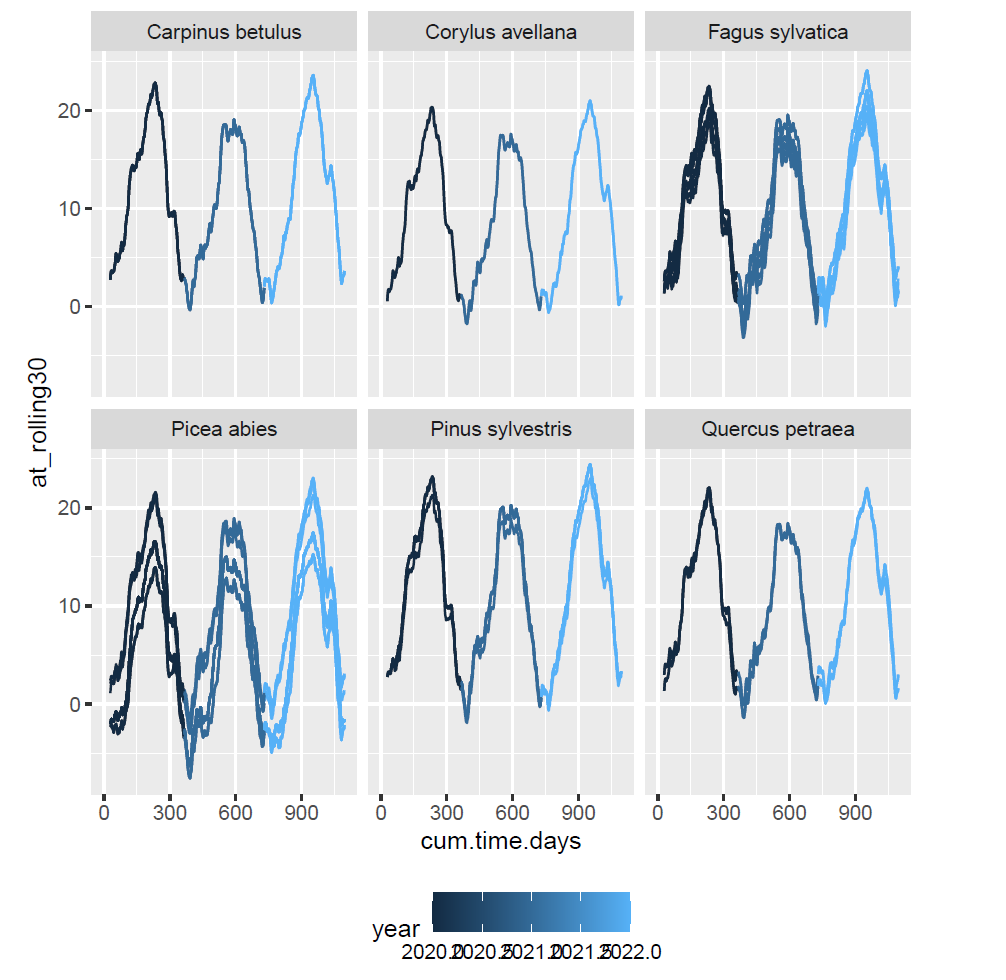

# Filter data


## Option 1: Filter rows with temperature < 0°C

In [148]:
bool_temp_below_0 = False
if bool_temp_below_0:
    # should be 5C
    below_5C = df_ts_series[df_ts_series['at_rolling30'] < 0]

    # Group by site and species and count occurrences
    low_temp_stats = below_5C.groupby(['site', 'species']).size().reset_index(name='count')

    # Show which site-species combinations had temps < 5°C
    print(low_temp_stats.sort_values(by='count', ascending=False))


In [149]:
print(df_ts_series.columns)
print("Unique months:", df_ts_series['month'].unique())

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'tree_index',
       'twd_rolling7', 'pr_rolling7', 'at_rolling7', 'ws_rolling7',
       'dp_rolling7', 'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7',
       'twd_rolling30', 'pr_rolling30', 'at_rolling30', 'ws_rolling30',
       'dp_rolling30', 'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'twd_SDrolling30', 'pr_SDrolling30', 'at_SDrolling30', 'ws_SDrolling30',
       'dp_SDrolling30', 'sr_SDrolling30', 'lr_SDrolling30',
       'day.of.year_SDrolling30', 'site_longitude', 'site_latitude',
       'site_easting', 'site_northing', 'mch_ind_closest', 'mch_easting',
       'mch_northing', 'mch_elevation', 'mch_site_eucldist', 'tree_type',
       'tree_type_enc'],
      dtype='object')
Unique months: [ 1 12 11 10  9  8  7  6  4  5  3  2]


Option 2: Filter only measurements taken during spring and summer months (March to August)


In [150]:
bool_spring_summer = False
if bool_spring_summer:
    # Filter for spring and summer months (March to August)
    spring_summer_months = [3, 4, 5, 6, 7, 8]
    df_ts_series = df_ts_series[df_ts_series['month'].isin(spring_summer_months)]

    # Check the number of rows after filtering
    print(f"Number of rows in spring and summer: {len(df_ts_series)}")
    

In [151]:
type(df_ts_series)
print(df_ts_series.columns)
df_ts_series = df_ts_series.dropna(subset=['twd_rolling30'])
print(df_ts_series['twd_rolling30'])

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day.of.year', 'month', 'week', 'tree_index',
       'twd_rolling7', 'pr_rolling7', 'at_rolling7', 'ws_rolling7',
       'dp_rolling7', 'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7',
       'twd_rolling30', 'pr_rolling30', 'at_rolling30', 'ws_rolling30',
       'dp_rolling30', 'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'twd_SDrolling30', 'pr_SDrolling30', 'at_SDrolling30', 'ws_SDrolling30',
       'dp_SDrolling30', 'sr_SDrolling30', 'lr_SDrolling30',
       'day.of.year_SDrolling30', 'site_longitude', 'site_latitude',
       'site_easting', 'site_northing', 'mch_ind_closest', 'mch_easting',
       'mch_northing', 'mch_elevation', 'mch_site_eucldist', 'tree_type',
       'tree_type_enc'],
      dtype='object')
1        0.981811
2        0.484780
3        0.470288
4        0.471271
5       

In [254]:
df_ts_series['site'] = df_ts_series['site'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)
df_ts_series['species'] = df_ts_series['species'].astype(str)
df_ts_series['year'] = df_ts_series['year'].astype(str)

#encoders = {}
#for col in ['site', 'species', 'year']:
#    le = LabelEncoder()
#    df_ts_series[col + '_enc'] = le.fit_transform(df_ts_series[col])
#    encoders[col] = le

# Proper encoding for categorical features
le_site = LabelEncoder()
le_species = LabelEncoder()
le_year = LabelEncoder()

df_ts_series['site_enc'] = le_site.fit_transform(df_ts_series['site'])
df_ts_series['species_enc'] = le_species.fit_transform(df_ts_series['species'])
df_ts_series['year_enc'] = le_year.fit_transform(df_ts_series['year'])
df_ts_series['species_enc'].unique()



array([2, 5, 0, 1, 3, 4])

In [255]:
df_ts_series

,Unnamed: 0,site,tree.id,ts,twd,pr,at,ws,dp,sr,...,ws_rolling30_scaled,dp_rolling30_scaled,sr_rolling30_scaled,lr_rolling30_scaled,day_cos_scaled,day_sin_scaled,mch_elevation_scaled,site_longitude_scaled,site_latitude_scaled,twd_rolling30_log_scaled
1,2,Bachtel-Forest,1,2022-01-25,1.472441,6.317190e-07,-0.877331,1.446561,-4.169493,87.166218,...,0.391656,0.359623,0.102553,0.341717,0.954409,0.708597,0.306349,0.733762,0.742504,0.358651
2,3,Bachtel-Forest,1,2021-12-30,0.000000,1.354897e-01,8.044978,1.798020,6.588012,10.034880,...,0.329787,0.382576,0.050238,0.455752,0.999926,0.491393,0.306349,0.733762,0.742504,0.207252
3,4,Bachtel-Forest,1,2021-12-04,0.102781,8.992752e-01,0.425184,3.472994,-0.203040,14.275745,...,0.374530,0.445085,0.103029,0.474476,0.946959,0.275885,0.306349,0.733762,0.742504,0.202109
4,5,Bachtel-Forest,1,2023-12-29,1.806872,2.466016e-01,5.700417,2.149112,2.415436,34.092931,...,0.470510,0.412384,0.032191,0.491207,0.999926,0.491370,0.306349,0.733762,0.742504,0.202459
5,6,Bachtel-Forest,1,2023-12-03,0.223431,1.555906e-02,-5.941142,2.207970,-7.932864,71.131448,...,0.554439,0.458429,0.046500,0.580397,0.946673,0.275315,0.306349,0.733762,0.742504,0.017337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61357,61358,Sihlwald-Forest,42,2022-01-27,0.552742,7.802187e-02,-1.438328,3.021568,-3.402347,75.874154,...,0.458962,0.395419,0.088984,0.375861,0.946959,0.724115,0.164128,0.643039,0.713696,0.135912
61358,61359,Sihlwald-Forest,42,2020-08-08,0.000000,5.519638e-07,21.852218,1.811116,15.480772,274.571957,...,0.316696,0.906590,0.692290,0.865615,0.102671,0.196471,0.164128,0.643039,0.713696,0.000000
61359,61360,Sihlwald-Forest,42,2021-12-31,0.329179,4.944194e-07,7.580756,3.141046,5.238666,50.878425,...,0.452393,0.435788,0.026929,0.539058,1.000000,0.500000,0.164128,0.643039,0.713696,0.129907
61360,61361,Sihlwald-Forest,42,2021-04-14,0.984201,1.427069e-03,1.823537,3.916790,-4.426657,222.192110,...,0.417800,0.364790,0.554067,0.386501,0.391138,0.988005,0.164128,0.643039,0.713696,0.335784


You map each day to a point on a circle. This way:

- Day 1 and Day 366 end up very close on the circle

- The relationship between days is smooth and continuous

- Models (especially linear or neural nets) can better learn time patterns

In [154]:
tree_min_max = df_ts_series.groupby('tree.id')['ts'].agg(['min', 'max']).reset_index()
print(tree_min_max)

    tree.id         min         max
0         1  2020-01-30  2023-12-30
1         2  2020-01-30  2023-12-30
2         3  2020-01-30  2023-12-30
3         4  2020-01-30  2023-12-30
4         5  2020-01-30  2023-12-30
5         6  2020-01-30  2023-12-30
6         7  2020-01-30  2023-12-30
7         8  2020-01-30  2023-12-30
8         9  2020-01-30  2023-12-30
9        10  2020-01-30  2023-12-30
10       11  2020-01-30  2023-07-19
11       12  2020-01-30  2023-12-30
12       13  2020-01-30  2023-12-30
13       14  2020-01-30  2023-12-30
14       15  2020-01-30  2023-12-28
15       16  2020-01-30  2023-12-30
16       17  2020-01-30  2023-12-30
17       18  2020-01-30  2023-06-14
18       19  2020-01-30  2023-12-30
19       22  2020-01-30  2023-12-30
20       23  2020-01-30  2023-12-30
21       24  2020-01-30  2023-12-30
22       25  2020-01-30  2023-12-30
23       26  2020-01-30  2023-12-30
24       27  2020-01-30  2023-12-30
25       28  2020-01-30  2023-12-30
26       29  2020-01-30  202

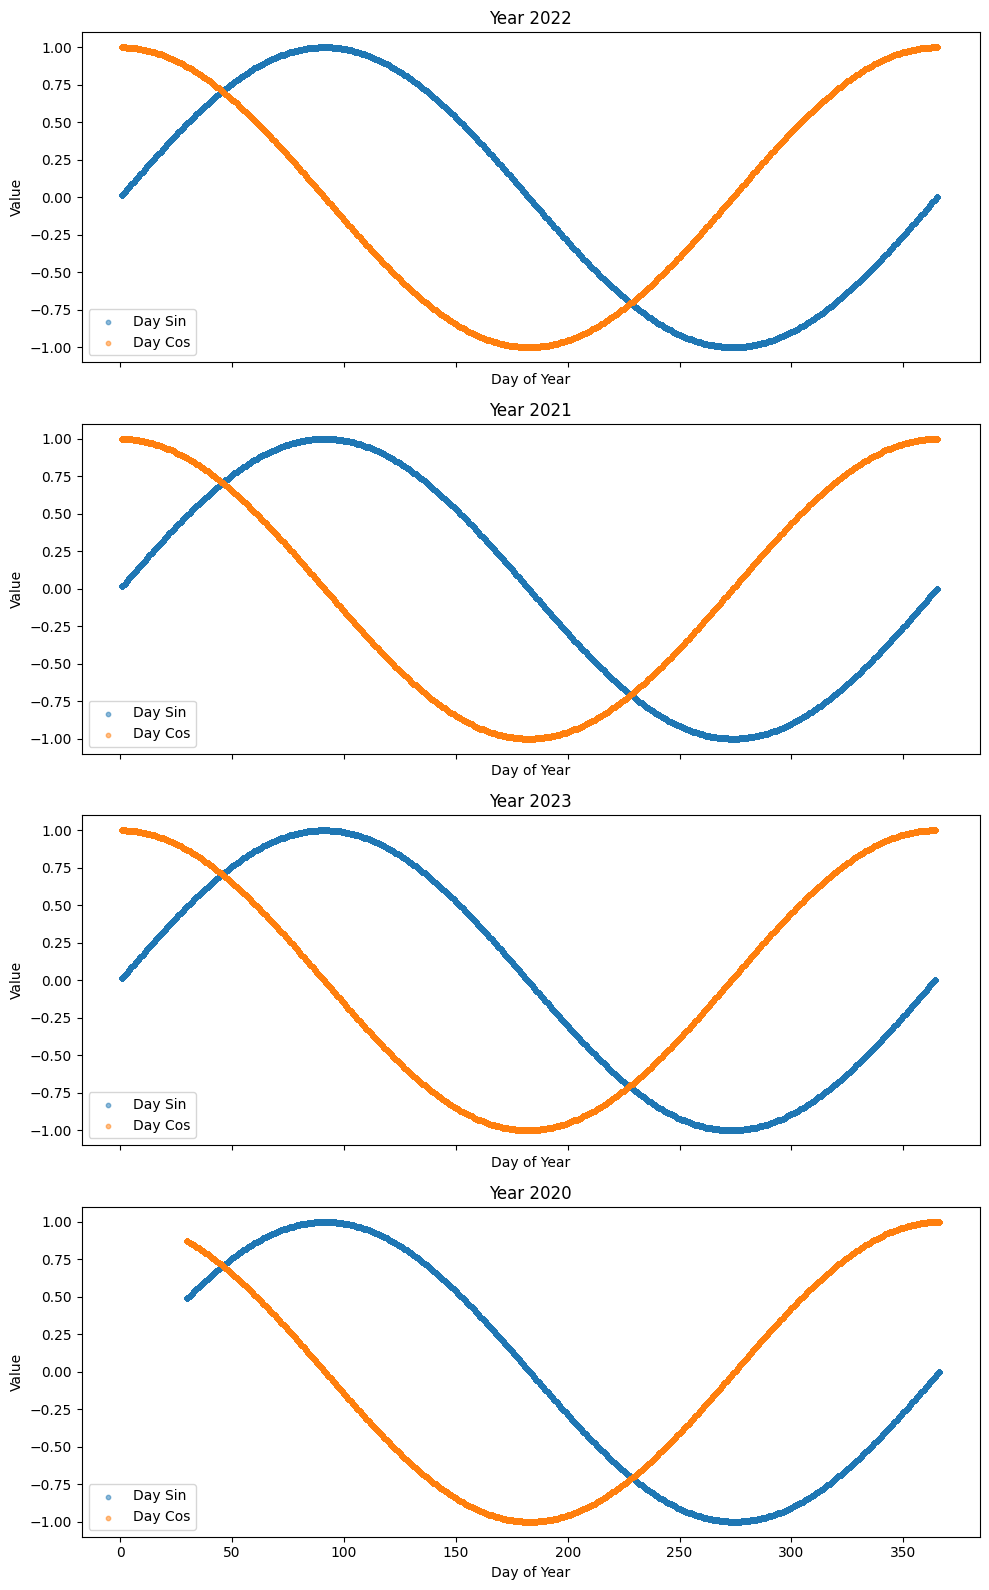

In [155]:
# change column name day.of.year to day_of_year, as numeric
df_ts_series.rename(columns={'day.of.year': 'day_of_year'}, inplace=True)


# Compute number of days per year (handles leap years)
days_per_year = df_ts_series.groupby('year')['day_of_year'].max().to_dict()

df_ts_series['days_in_year'] = df_ts_series['year'].map(days_per_year)
df_ts_series['day_sin'] = np.sin(2 * np.pi * df_ts_series['day_of_year'] / df_ts_series['days_in_year'])
df_ts_series['day_cos'] = np.cos(2 * np.pi * df_ts_series['day_of_year'] / df_ts_series['days_in_year'])

years = df_ts_series['year'].unique()
n_years = len(years)
nrows = 4  # Number of rows in the subplot grid
ncols = 1  # Number of columns in the subplot grid
# plot day_sin and day_cos as points (not lines)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows), sharex=True, sharey=True)

for ax, year in zip(axes.flat, years):
    group = df_ts_series[df_ts_series['year'] == year]
    ax.scatter(group['day_of_year'], group['day_sin'], label='Day Sin', alpha=0.5, s=10)
    ax.scatter(group['day_of_year'], group['day_cos'], label='Day Cos', alpha=0.5, s=10)
    ax.set_title(f'Year {year}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Value')
    ax.legend()

# Hide any unused subplots
for i in range(n_years, nrows * ncols):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()

In [156]:
days_per_year

{'2020': 366, '2021': 365, '2022': 365, '2023': 364}

In [256]:
df_ts_series.groupby('year')['day_of_year'].min().to_dict()


{'2020': 30, '2021': 1, '2022': 1, '2023': 1}

2020 starts at day 30 because of the rolling average. The first 30 days are not available in the dataset.

In [262]:
print(df_ts_series.columns)
df_ts_series["species_enc"].unique()

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day_of_year', 'month', 'week', 'tree_index',
       'twd_rolling7', 'pr_rolling7', 'at_rolling7', 'ws_rolling7',
       'dp_rolling7', 'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7',
       'twd_rolling30', 'pr_rolling30', 'at_rolling30', 'ws_rolling30',
       'dp_rolling30', 'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'twd_SDrolling30', 'pr_SDrolling30', 'at_SDrolling30', 'ws_SDrolling30',
       'dp_SDrolling30', 'sr_SDrolling30', 'lr_SDrolling30',
       'day.of.year_SDrolling30', 'site_longitude', 'site_latitude',
       'site_easting', 'site_northing', 'mch_ind_closest', 'mch_easting',
       'mch_northing', 'mch_elevation', 'mch_site_eucldist', 'tree_type',
       'tree_type_enc', 'site_enc', 'species_enc', 'year_enc', 'days_in_year',
       'day_sin', 'day_cos', 'twd_rolling30_log'

array([2, 5, 0, 1, 3, 4])

In [263]:
print(df_ts_series['mch_elevation'])

1        882.140575
2        882.140575
3        882.140575
4        882.140575
5        882.140575
            ...    
61357    722.265575
61358    722.265575
61359    722.265575
61360    722.265575
61361    722.265575
Name: mch_elevation, Length: 56067, dtype: float64


In [264]:
print(df_ts_series['site'] )
print(df_ts_series['site_enc'] )

1         Bachtel-Forest
2         Bachtel-Forest
3         Bachtel-Forest
4         Bachtel-Forest
5         Bachtel-Forest
              ...       
61357    Sihlwald-Forest
61358    Sihlwald-Forest
61359    Sihlwald-Forest
61360    Sihlwald-Forest
61361    Sihlwald-Forest
Name: site, Length: 56067, dtype: object
1         0
2         0
3         0
4         0
5         0
         ..
61357    18
61358    18
61359    18
61360    18
61361    18
Name: site_enc, Length: 56067, dtype: int64


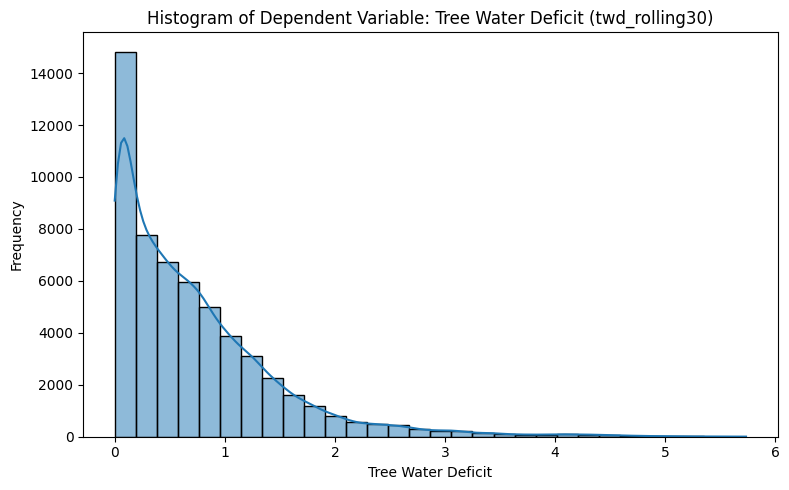

In [265]:
plt.figure(figsize=(8, 5))
sns.histplot(df_ts_series['twd_rolling30'], bins=30, kde=True)
plt.title('Histogram of Dependent Variable: Tree Water Deficit (twd_rolling30)')
plt.xlabel('Tree Water Deficit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

We have a Severely skewed target distribution
Most Tree Water Deficit (TWD) values are near zero, with a long tail of rare high values.

If we do not normalize, MSE is dominated by frequent low values:
➔ The model prefers to predict near-zero to minimize overall loss.
➔ Peaks are systematically underpredicted.

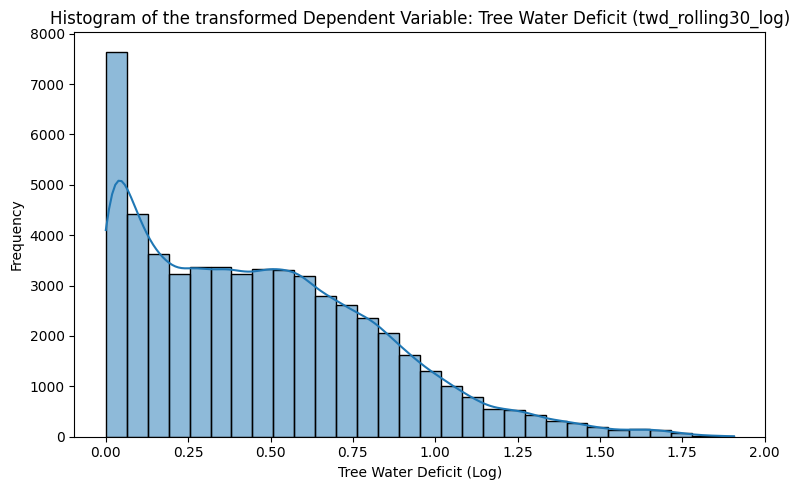

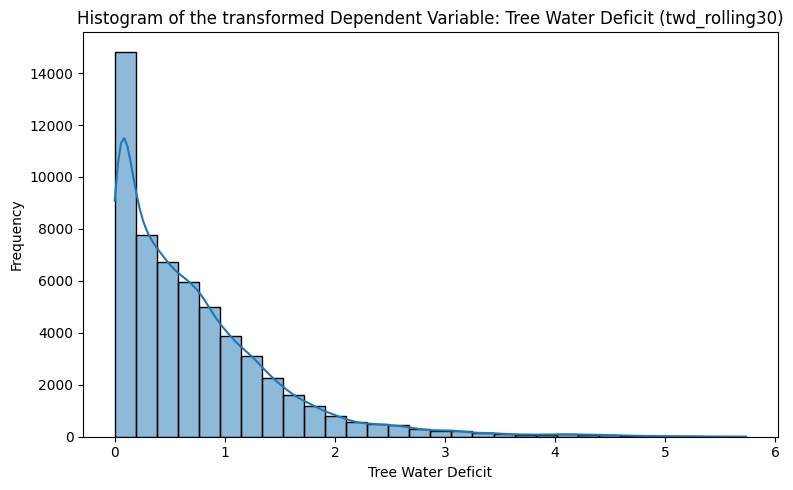

np.float64(0.0)

In [160]:
df_ts_series['twd_rolling30_log'] = np.log1p(df_ts_series['twd_rolling30'])

plt.figure(figsize=(8, 5))
sns.histplot(df_ts_series['twd_rolling30_log'], bins=30, kde=True)
plt.title('Histogram of the transformed Dependent Variable: Tree Water Deficit (twd_rolling30_log)')
plt.xlabel('Tree Water Deficit (Log)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df_ts_series['twd_rolling30'], bins=30, kde=True)
plt.title('Histogram of the transformed Dependent Variable: Tree Water Deficit (twd_rolling30)')
plt.xlabel('Tree Water Deficit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

df_ts_series['twd_rolling30'].min()

In [161]:
# Initialize dictionary to store scalers
scalers = {}

# Scale each feature individually
for col in features_to_scale:
    scaler = MinMaxScaler()
    df_ts_series[col + '_scaled'] = scaler.fit_transform(df_ts_series[[col]])
    scalers[col] = scaler


In [162]:
print(df_ts_series.columns)
features_to_scale

Index(['Unnamed: 0', 'site', 'tree.id', 'ts', 'twd', 'pr', 'at', 'ws', 'dp',
       'sr', 'lr', 'series', 'species', 'year', 'diff.ts', 'diff.days',
       'cum.time.days', 'day_of_year', 'month', 'week', 'tree_index',
       'twd_rolling7', 'pr_rolling7', 'at_rolling7', 'ws_rolling7',
       'dp_rolling7', 'sr_rolling7', 'lr_rolling7', 'day.of.year_rolling7',
       'twd_rolling30', 'pr_rolling30', 'at_rolling30', 'ws_rolling30',
       'dp_rolling30', 'sr_rolling30', 'lr_rolling30', 'day.of.year_rolling30',
       'twd_SDrolling30', 'pr_SDrolling30', 'at_SDrolling30', 'ws_SDrolling30',
       'dp_SDrolling30', 'sr_SDrolling30', 'lr_SDrolling30',
       'day.of.year_SDrolling30', 'site_longitude', 'site_latitude',
       'site_easting', 'site_northing', 'mch_ind_closest', 'mch_easting',
       'mch_northing', 'mch_elevation', 'mch_site_eucldist', 'tree_type',
       'tree_type_enc', 'site_enc', 'species_enc', 'year_enc', 'days_in_year',
       'day_sin', 'day_cos', 'twd_rolling30_log'

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'site_longitude',
 'site_latitude',
 'twd_rolling30_log']

## Create input sequences

In [266]:

# Create list of scaled dynamic features
dynamic_scaled_features = [f"{feat}_scaled" for feat in dynamic_features]

#static_scaled_features = ['site_enc', 'species_enc', 'mch_elevation_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled' ]
static_scaled_features = ['species_enc', 'mch_elevation_scaled', 'site_longitude_scaled', 'site_latitude_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled', 'tree_type_enc' ]
target_scaled = target_column + '_scaled'
print(dynamic_scaled_features)
print(static_scaled_features)
print(target_scaled)


['pr_rolling30_scaled', 'at_rolling30_scaled', 'ws_rolling30_scaled', 'dp_rolling30_scaled', 'sr_rolling30_scaled', 'lr_rolling30_scaled', 'twd_rolling30_log_scaled']
['species_enc', 'mch_elevation_scaled', 'site_longitude_scaled', 'site_latitude_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled', 'tree_type_enc']
twd_rolling30_log_scaled


In [267]:
# Find peak indices (top 5%) by tree_id
peak_mask = df_ts_series['twd_rolling30'] > df_ts_series.groupby('tree.id')['twd_rolling30'].transform(lambda x: x.quantile(0.95))
peak_indices_by_tree =  df_ts_series[peak_mask].index
peak_indices_by_tree

Index([   16,    22,    58,    64,   100,   106,   142,   184,   195,   226,
       ...
       60935, 60949, 60963, 60977, 60991, 61289, 61331, 61332, 61350, 61360],
      dtype='int64', length=2821)

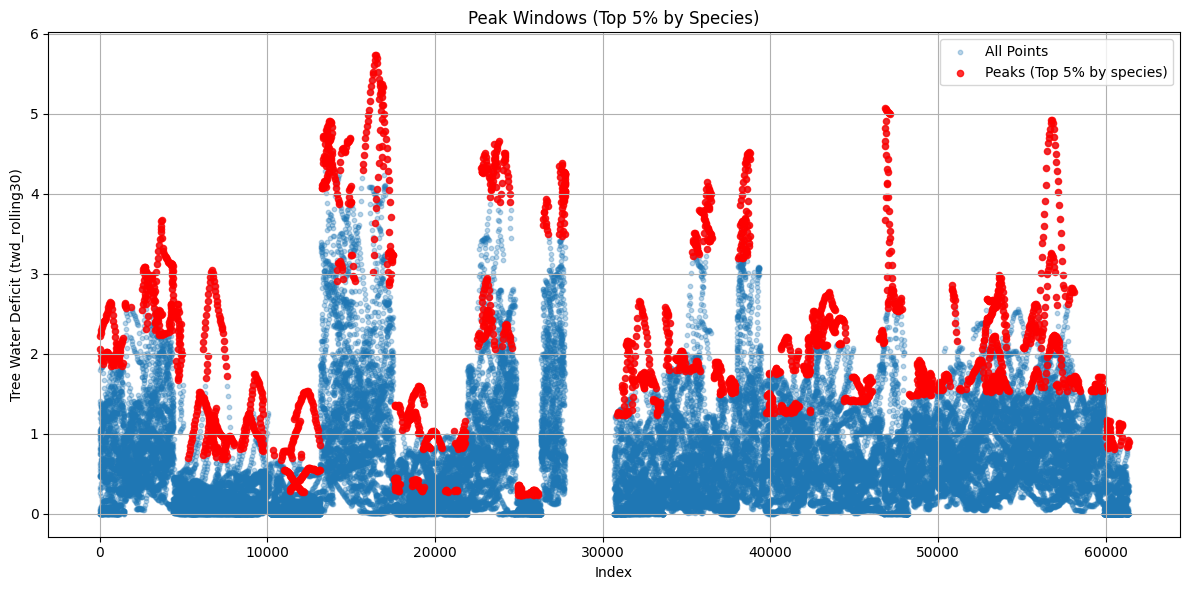

In [165]:
# Visualize peak indices by species
plt.figure(figsize=(12, 6))
plt.scatter(df_ts_series.index, df_ts_series['twd_rolling30'], label='All Points', alpha=0.3, s=10)
plt.scatter(peak_indices_by_tree, df_ts_series.loc[peak_indices_by_tree, 'twd_rolling30'], 
            color='red', label='Peaks (Top 5% by species)', alpha=0.8, s=20)
plt.xlabel('Index')
plt.ylabel('Tree Water Deficit (twd_rolling30)')
plt.title('Peak Windows (Top 5% by Species)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [268]:

def create_sequences(df, seq_len, forecast_horizon=1):
    X_seq, X_static, y, meta = [], [], [], []
    for series_id, group in df.groupby('tree.id'):
        if len(group) < seq_len + forecast_horizon:
            continue
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            window = group.iloc[i:i+seq_len]
            target_window = group.iloc[i+seq_len:i+seq_len+forecast_horizon]
            
            X_seq.append(window[dynamic_scaled_features].values)
            static = group.iloc[i][static_scaled_features].values
            X_static.append(static)
            y.append(target_window[target_scaled].values)

        
            meta.append({
                'tree_id': series_id,
                'site_longitude': group.iloc[i]['site_longitude'],
                'site_latitude': group.iloc[i]['site_latitude'],
                'species': group.iloc[i]['species'],
                'year': group.iloc[i]['year'], 
                'timestamps': window['cum.time.days'].tolist(),  # assuming your timestamp column is 'date',
                'day_sin': group.iloc[i]['day_sin'],
                'day_cos': group.iloc[i]['day_cos'],
                'tree_type': group.iloc[i]['tree_type'],
                'start_index': window.index[0]
            })
    
    return np.array(X_seq), np.array(X_static), np.array(y), meta


In [273]:
static_scaled_features

['species_enc',
 'mch_elevation_scaled',
 'site_longitude_scaled',
 'site_latitude_scaled',
 'year_enc',
 'day_sin_scaled',
 'day_cos_scaled',
 'tree_type_enc']

Why the test set should be temporally after the training set
If your model sees future data during training, it will:
1. Leak information it wouldn’t have in reality.
2. Artificially inflate performance metrics.
3. Fail in production, where only past data is available to forecast the future.

In [269]:
# --- Split by time for each tree ---

# Set the percentage of data to use for the test set (e.g., 20%)
test_percent = 0.2  # Change this value as needed

train_indices, test_indices = [], []

for tree_id, group in df_ts_series.groupby('tree.id'):
    group_sorted = group.sort_values('cum.time.days')
    n = len(group_sorted)
    split_point = int(n * (1 - test_percent))
    train_indices.extend(group_sorted.index[:split_point])
    test_indices.extend(group_sorted.index[split_point:])

df_train = df_ts_series.loc[train_indices].reset_index(drop=True)
df_test = df_ts_series.loc[test_indices].reset_index(drop=True)

# 2. Generate sequences separately for train and test sets
X_seq_train, X_static_train, y_train, meta_train = create_sequences(df=df_train, seq_len=SEQ_LEN, forecast_horizon=forec_horizon)
X_seq_test, X_static_test, y_test, meta_test = create_sequences(df=df_test, seq_len=SEQ_LEN, forecast_horizon=forec_horizon)

In [275]:
print(X_static_train.shape) # nb samples
print(X_seq_train.shape)
# dependent on static_scaled_features
species_col = X_static_train[:, 0]
# Count samples per species
species_counts = pd.Series(species_col).value_counts()
print(species_counts)
unique_species = np.unique(X_static_train[:, 0])
print(unique_species)

(42427, 8)
(42427, 60, 7)
3    15922
2    10716
4     4949
5     4336
0     4336
1     2168
Name: count, dtype: int64
[np.int64(0) np.int64(1) np.int64(2) np.int64(3) np.int64(4) np.int64(5)]


In [169]:
def oversample_peaks(X_seq, X_static, y, meta, peak_indices, factor=3):
    peak_indices_set = set(peak_indices)  # Faster lookup
    oversampled_X_seq, oversampled_X_static, oversampled_y, oversampled_meta = [], [], [], []
    for i, m in enumerate(meta):
        # m['start_index'] is the first index of the sequence in the original DataFrame
        # m['timestamps'] is a list of timestamps, but you want to check DataFrame indices
        seq_indices = range(m['start_index'], m['start_index'] + len(m['timestamps']))
        if any(idx in peak_indices_set for idx in seq_indices):
            for _ in range(factor):
                oversampled_X_seq.append(X_seq[i])
                oversampled_X_static.append(X_static[i])
                oversampled_y.append(y[i])
                oversampled_meta.append(m)
        else:
            oversampled_X_seq.append(X_seq[i])
            oversampled_X_static.append(X_static[i])
            oversampled_y.append(y[i])
            oversampled_meta.append(m)
    return (np.array(oversampled_X_seq), np.array(oversampled_X_static), np.array(oversampled_y), oversampled_meta)

bool_oversample_peaks = False
if bool_oversample_peaks:
    X_seq_train, X_static_train, y_train, meta_train = oversample_peaks(
    X_seq_train, X_static_train, y_train, meta_train, peak_indices_by_tree, factor=3
)


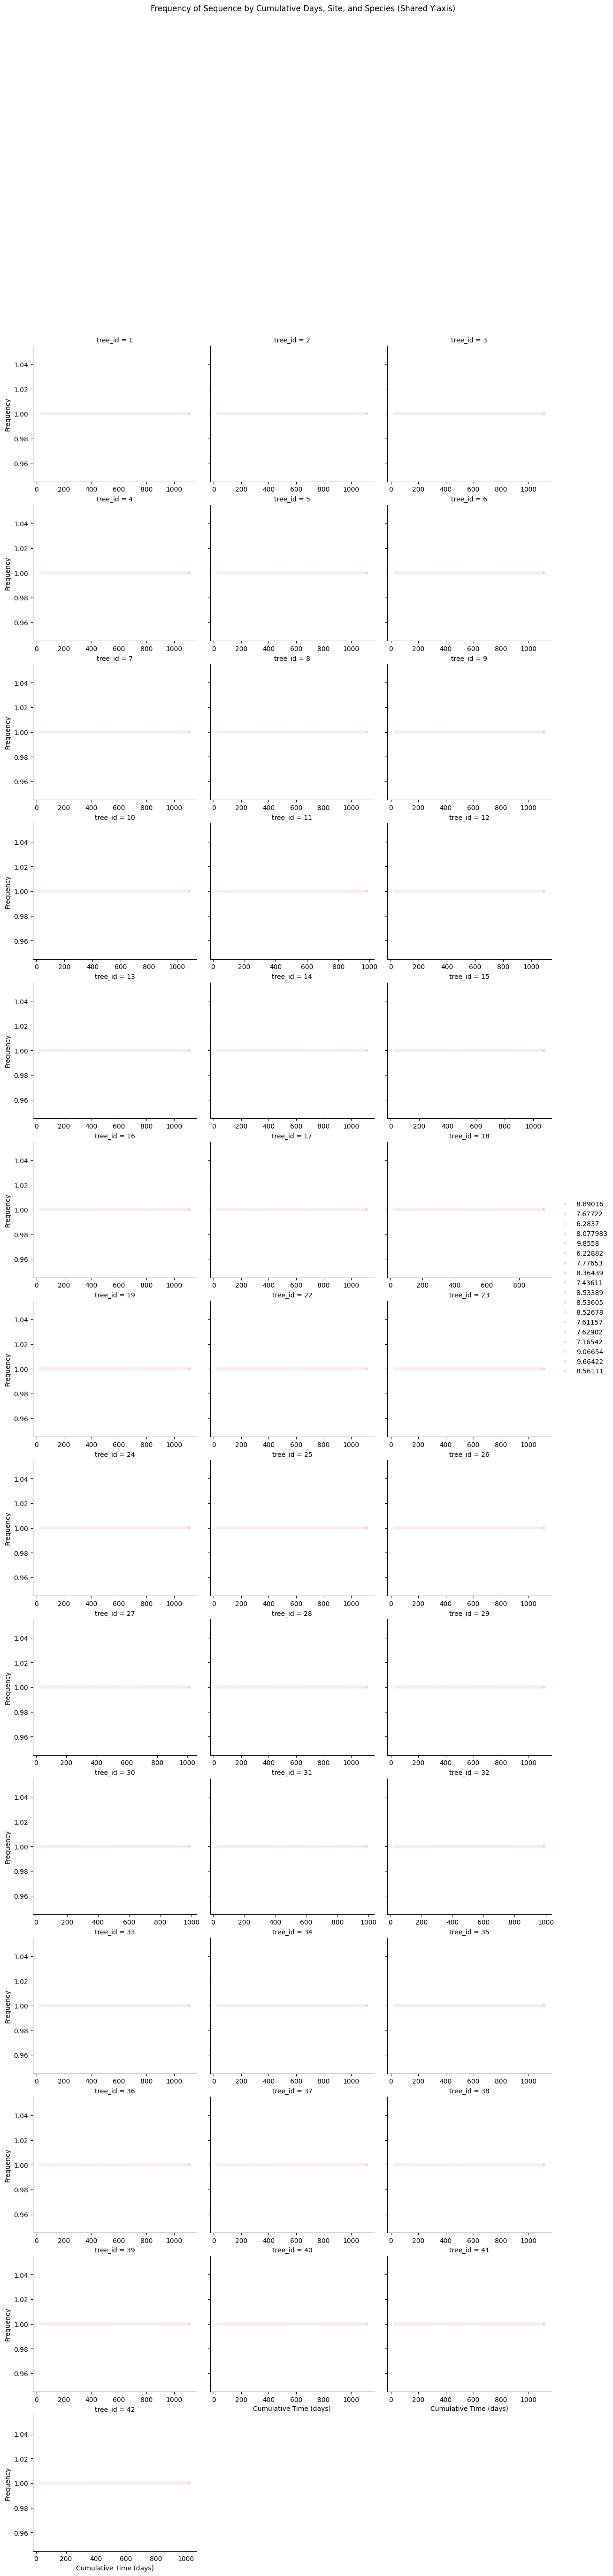

In [170]:
# Add cum.time.days for the first timestamp in each sequence
meta_df = pd.DataFrame(meta_train)
meta_df['cum_time_days'] = meta_df['timestamps'].apply(lambda x: x[0])

# Group by tree_id, site_longitude, site_latitude, species, cum_time_days and count frequency
freq_df = meta_df.groupby(['tree_id', 'site_longitude', 'site_latitude', 'species', 'cum_time_days']).size().reset_index(name='frequency')

# FacetGrid per species
g = sns.FacetGrid(freq_df, col="tree_id", col_wrap=3, height=4, sharey=True, sharex=False)
g.map_dataframe(sns.scatterplot, x="cum_time_days", y="frequency", hue="site_longitude", alpha=0.7, s=20)
g.add_legend()
g.set_axis_labels("Cumulative Time (days)", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Frequency of Sequence by Cumulative Days, Site, and Species (Shared Y-axis)")
plt.show()

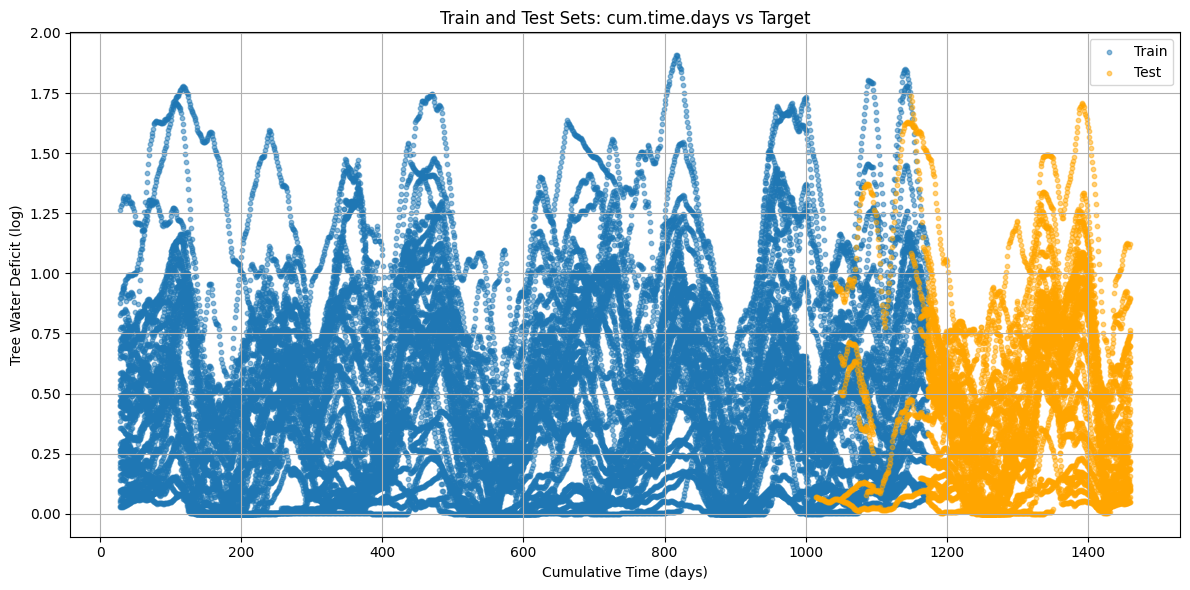

In [171]:
plt.figure(figsize=(12, 6))
plt.scatter(df_train['cum.time.days'], df_train[target_column], label='Train', alpha=0.5, s=10)
plt.scatter(df_test['cum.time.days'], df_test[target_column], label='Test', alpha=0.5, s=10, color='orange')
plt.xlabel('Cumulative Time (days)')
plt.ylabel('Tree Water Deficit (log)')
plt.title('Train and Test Sets: cum.time.days vs Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [172]:
tree_info = meta_test[2] # example
print(tree_info)

{'tree_id': 1, 'site_longitude': np.float64(8.89016), 'site_latitude': np.float64(47.29413), 'species': 'Fagus sylvatica', 'year': '2023', 'timestamps': [1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234], 'day_sin': np.float64(0.9820275556534303), 'day_cos': np.float64(0.1887375954529167), 'tree_type': 'Broadleaf deciduous', 'start_index': np.int64(2)}


In [173]:

max_site_enc = int(df_ts_series['site_enc'].max())
print("Max site_enc:", max_site_enc)
max_species_enc = int(df_ts_series['species_enc'].max())
print("Max species_enc:", max_species_enc)
max_year_enc = int(df_ts_series['year_enc'].max())
print("Max year_enc:", max_year_enc)
print(df_ts_series['year_enc'].unique())


Max site_enc: 18
Max species_enc: 5
Max year_enc: 3
[2 1 3 0]


## Define transformer block

R² is not differentiable in a stable way, Use R² only as a monitoring metric during training. R2 pertains to the whole batch, 

If your model predicts forecast_horizon = 7 future steps (i.e., y_pred.shape = (batch_size, 7)), you can compute R² per output like this:

In [180]:
def transformer_block(x, d_model, num_heads, ff_dim, dropout=0.1):
    # Ensure: d_model == num_heads * head_size
    head_size = d_model // num_heads
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout
    )(x, x)  # -> (..., d_model)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(d_model)(ff_output)
    return LayerNormalization(epsilon=1e-6)(x + ff_output)


In [175]:
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

In [176]:
def r2_score_per_timestep(y_true, y_pred):
    # Compute R² for each time step separately and return the average
    
    diff = y_true - y_pred
    #tf.print("Shape of y_true:", tf.shape(y_true)) # [31 1]
    # tf.print("Shape of y_pred:", tf.shape(y_pred))  # [31 1]
    
    ss_res = K.sum(K.square(diff), axis=0)
    ss_tot = K.sum(K.square(y_true - K.mean(y_true, axis=0)), axis=0)
    r2 = 1 - (ss_res / (ss_tot + K.epsilon()))
    return K.mean(r2)

In [177]:
# Define your species weights (example: all 1.0)#
# species_weights = np.ones(df_ts_series['species_enc'].max() + 1)
species_counts = df_ts_series['species_enc'].value_counts().sort_index().values
species_weights = np.array([1 / count for count in species_counts])
species_weights /= np.sum(species_weights) / len(species_weights)  # normalize to mean 1

# using mean
def weighted_rmse_wrapper(species_weights):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true_values = y_true[:, :-1]
        species_ids = tf.cast(y_true[:, -1], tf.int32)
        mse = tf.square(y_true_values - y_pred) # Standard squared error between predictions and true values.
        # tf.gather() looks up the weight for each sample based on its species ID.
        # weights will have the same length as the batch size, each corresponding to the sample’s species.
        weights = tf.gather(tf.constant(species_weights, dtype=tf.float32), species_ids)
        weighted_mse = tf.reduce_mean(mse * weights)
        return tf.sqrt(weighted_mse)
    return loss

# using quantile loss
def weighted_quantile_loss_wrapper(species_weights, q=0.5):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_true_values = y_true[:, :-1]
        species_ids = tf.cast(y_true[:, -1], tf.int32)

        # Quantile loss (pinball loss)
        error = y_true_values - y_pred
        quantile_loss = tf.maximum(q * error, (q - 1) * error)

        # Species weights
        weights = tf.gather(tf.constant(species_weights, dtype=tf.float32), species_ids)

        # Final weighted quantile loss
        return tf.reduce_mean(quantile_loss * weights)
    return loss

In [178]:
print(species_counts)
for i, weight in enumerate(species_weights):
    print(f"species_enc: {i}, species: {le_species.inverse_transform([i])[0]}, weight: {weight}")

[ 5724  2862 14154 21040  6563  5724]
species_enc: 0, species: Carpinus betulus, weight: 1.0813491776149198
species_enc: 1, species: Corylus avellana, weight: 2.1626983552298396
species_enc: 2, species: Fagus sylvatica, weight: 0.43730695864545716
species_enc: 3, species: Picea abies, weight: 0.29418453862489546
species_enc: 4, species: Pinus sylvestris, weight: 0.943111792269968
species_enc: 5, species: Quercus petraea, weight: 1.0813491776149198


## Build and compile the transformer model

In [181]:
n_features = X_seq_test.shape[-1]
print(n_features)

# Inputs
seq_input = Input(shape=(SEQ_LEN, n_features), name='seq_input')
d_model = 64
# Project per-timestep features to d_model
proj = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(d_model))(seq_input)

#site_input = Input(shape=(1,), name='site')
species_input = Input(shape=(1,), name='species')
tree_type_input = Input(shape=(1,), name="tree_type")

mch_input = Input(shape=(1,), name='mch_input')
year_input = Input(shape=(1,), name='year_input')
day_sin_input = Input(shape=(1,), name='day_sin')
day_cos_input = Input(shape=(1,), name='day_cos')
site_long_input = Input(shape=(1,), name='site_longitude')
site_lat_input = Input(shape=(1,), name='site_latitude')

# Static embeddings
# Always set input_dim = max value in column + 1.
#site_emb = Embedding(input_dim= 19, output_dim=2)(site_input)
species_emb = Embedding(input_dim= 6, output_dim=4)(species_input)
#site_vec = Flatten()(site_emb)
species_vec = Flatten()(species_emb)
#tree_type_emb = Embedding(input_dim=2, output_dim=1)(tree_type_input)  # small embedding
#tree_type_vec = Flatten()(tree_type_emb)


# Positional encoding
#positions = tf.range(start=0, limit=SEQ_LEN, delta=1)
#pos_embedding = Embedding(input_dim=SEQ_LEN, output_dim=n_features)(positions)
#pos_encoded = seq_input + pos_embedding
positions = tf.range(start=0, limit=SEQ_LEN, delta=1)
pos_embedding = tf.keras.layers.Embedding(input_dim=SEQ_LEN, output_dim=d_model)(positions)
pos_embedding = tf.reshape(pos_embedding, (1, SEQ_LEN, d_model))  # broadcast over batch
pos_encoded = proj + pos_embedding

# Transformer block
# temporal feature learning capacity
# More transformer blocks stacked enhances temporal pattern learning.
# Example: 4 heads × 16 key_dim = 64
x = transformer_block(pos_encoded, d_model=d_model, num_heads=4, ff_dim=128, dropout=0.2)
x = Dropout(0.2)(x)
x = transformer_block(x, d_model=d_model, num_heads=4, ff_dim=128, dropout=0.2)
x = Dropout(0.2)(x)
x = GlobalAveragePooling1D()(x)


# Combine with static
#static_vec = Concatenate()([site_vec, species_vec, mch_input, year_input, day_sin_input, day_cos_input])
static_vec = Concatenate()([site_long_input, site_lat_input, species_vec, mch_input, year_input, day_sin_input, day_cos_input, tree_type_input])
combined = Concatenate()([x, static_vec])

# Output, use RELU or softplus to avoid negative values
# forecast of the next time step (1-step-ahead).
output = Dense(forec_horizon, activation='softplus')(combined)

# weight_decay=0 disables the benefits of AdamW
# learning rate is a scalar multiplier for the computed gradients.
#Typical values, For Adam or AdamW optimizers:
#Common: 1e-3 (0.001)
#Smaller for fine-tuning or transformers: 1e-4 (0.0001) or 1e-5 (0.00001)
optimizer = AdamW(learning_rate=1e-6, weight_decay=1e-4)
#model = Model(inputs=[seq_input, mch_input, site_input, species_input, year_input, day_sin_input, day_cos_input], outputs=output)
model = Model(inputs=[seq_input, mch_input, site_long_input, site_lat_input, species_input, year_input, day_sin_input, day_cos_input, tree_type_input], outputs=output)
model.compile(
    optimizer=optimizer,
    # loss='mse', # Still use MSE or MAE for training
    loss = weighted_rmse_wrapper(species_weights),
    #loss = weighted_quantile_loss_wrapper(species_weights, q=0.7),
    #loss = quantile_loss(0.5),
    metrics=[r2_score_per_timestep]
    )  # You may consider 'mae' for multi-step
model.summary()


7


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 60, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 60, 64)    │        512 │ seq_input[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 60, 64)    │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     16,640 │ add_16[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 60, 64)    │          0 │ add_16[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 60, 64)    │      8,256 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 60, 64)    │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     16,640 │ dropout_21[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 60, 64)    │          0 │ dropout_21[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 60, 64)    │      8,256 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 67,556 (263.89 KB)

 Trainable params: 67,556 (263.89 KB)

 Non-trainable params: 0 (0.00 B)

In [182]:
static_vec

<KerasTensor shape=(None, 11), dtype=float32, sparse=False, ragged=False, name=keras_tensor_337>

## Train the model

In [183]:
X_static_train

array([[np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7462740339769321), np.float64(0.9351426205150777),
        np.int64(0)],
       [np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7537075466469227), np.float64(0.930850879974034),
        np.int64(0)],
       [np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7610662905384125), np.float64(0.9264321657010799),
        np.int64(0)],
       ...,
       [np.int64(2), np.float64(0.1641276548426548),
        np.float64(0.6430391124296244), ...,
        np.float64(0.027201806286428598), np.float64(0.6626710423559897),
        np.int64(0)],
       [np.int64(2), np.float64(0.1641276548426548),
        np.float64(0.6430391124296244), ...,
        np.float64(0.030071971029052347), np.float64(0.670785384583928),
        np.int64(0)],
       [np.int64(2), np

In [184]:
features_to_scale

['pr_rolling30',
 'at_rolling30',
 'ws_rolling30',
 'dp_rolling30',
 'sr_rolling30',
 'lr_rolling30',
 'day_cos',
 'day_sin',
 'mch_elevation',
 'site_longitude',
 'site_latitude',
 'twd_rolling30_log']

In [186]:
class PeriodicCheckpoint(Callback):
    def __init__(self, save_path, frequency):
        super().__init__()
        self.save_path = save_path
        self.frequency = frequency

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.frequency == 0:
            filepath = os.path.join(self.save_path, f"model_epoch_{epoch+1}.h5")
            self.model.save(filepath)
            print(f"✅ Saved model at epoch {epoch + 1} to {filepath}")

     

In [187]:
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_callback = PeriodicCheckpoint(save_path=checkpoint_dir, frequency=checkpoint_frequency)       

In [188]:
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience= my_patience,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

In [189]:
X_static_train

array([[np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7462740339769321), np.float64(0.9351426205150777),
        np.int64(0)],
       [np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7537075466469227), np.float64(0.930850879974034),
        np.int64(0)],
       [np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7610662905384125), np.float64(0.9264321657010799),
        np.int64(0)],
       ...,
       [np.int64(2), np.float64(0.1641276548426548),
        np.float64(0.6430391124296244), ...,
        np.float64(0.027201806286428598), np.float64(0.6626710423559897),
        np.int64(0)],
       [np.int64(2), np.float64(0.1641276548426548),
        np.float64(0.6430391124296244), ...,
        np.float64(0.030071971029052347), np.float64(0.670785384583928),
        np.int64(0)],
       [np.int64(2), np

In [283]:
# For training
y_train_with_species = np.concatenate([
    y_train.astype(np.float32), 
    X_static_train[:, 0].reshape(-1, 1).astype(np.float32)  # species_enc is column 2
], axis=1)

# For testing
y_test_with_species = np.concatenate([
    y_test.astype(np.float32), 
    X_static_test[:, 0].reshape(-1, 1).astype(np.float32)
], axis=1)

X_static_train.shape
# should be 5 species
np.unique(y_test_with_species[:, 1])


array([0., 1., 2., 3., 4., 5.], dtype=float32)

For a non-random validation split for time series forecasting, it should be temporal. This means the validation set should contain data from a later time period than the training set, to mimic real-world forecasting and avoid data leakage.

In [284]:
# Temporal validation split for each tree in training set
val_indices = []
train_indices_actual = []

for tree_id, group in df_train.groupby('tree.id'):
    group_sorted = group.sort_values('cum.time.days')
    n = len(group_sorted)
    split_point = int(n * 0.85)  # 85% train, 15% val for each tree
    train_indices_actual.extend(group_sorted.index[:split_point])
    val_indices.extend(group_sorted.index[split_point:])

# Use start_index from meta_train to select sequences
seq_start_indices = [m['start_index'] for m in meta_train]

train_mask = np.isin(seq_start_indices, train_indices_actual)
val_mask = np.isin(seq_start_indices, val_indices)

X_seq_train_actual = X_seq_train[train_mask]
X_static_train_actual = X_static_train[train_mask]
y_train_actual = y_train_with_species[train_mask]

X_seq_val = X_seq_train[val_mask]
X_static_val = X_static_train[val_mask]
y_val = y_train_with_species[val_mask]

In [291]:
X_static_train_actual.shape
X_static_train_actual


array([[np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7462740339769321), np.float64(0.9351426205150777),
        np.int64(0)],
       [np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7537075466469227), np.float64(0.930850879974034),
        np.int64(0)],
       [np.int64(2), np.float64(0.30634938285332924),
        np.float64(0.7337619727707347), ...,
        np.float64(0.7610662905384125), np.float64(0.9264321657010799),
        np.int64(0)],
       ...,
       [np.int64(2), np.float64(0.1641276548426548),
        np.float64(0.6430391124296244), ...,
        np.float64(0.4016635551032119), np.float64(0.00976541981918394),
        np.int64(0)],
       [np.int64(2), np.float64(0.1641276548426548),
        np.float64(0.6430391124296244), ...,
        np.float64(0.39323954228010205), np.float64(0.01153075361140915),
        np.int64(0)],
       [np.int64(2), np

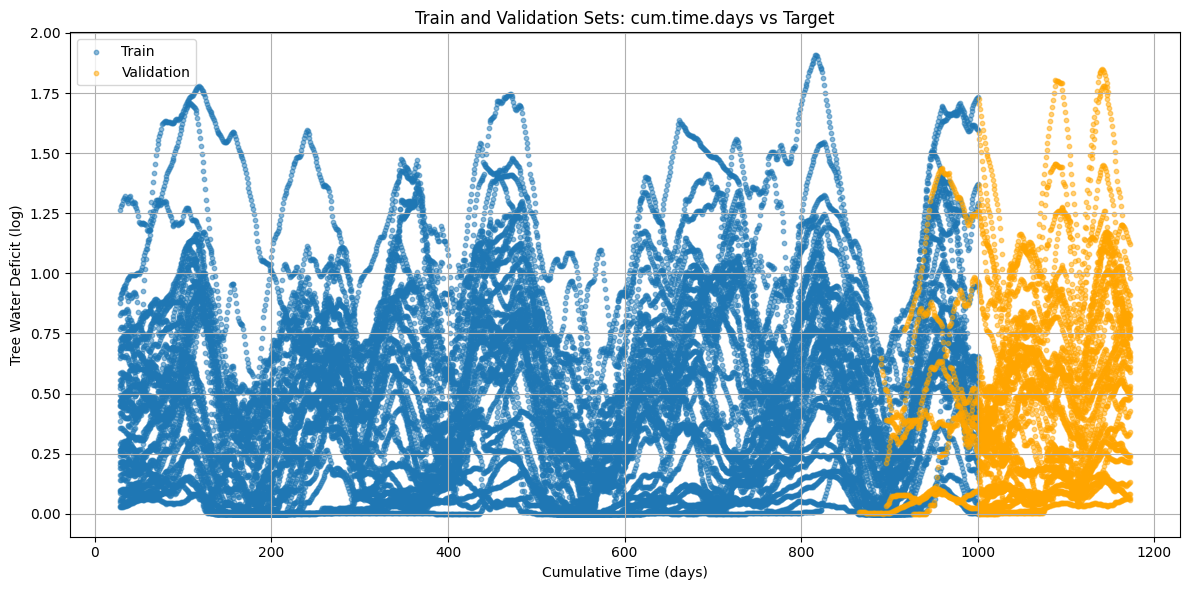

In [285]:
plt.figure(figsize=(12, 6))
plt.scatter(df_train.loc[train_indices_actual, 'cum.time.days'], df_train.loc[train_indices_actual, target_column], label='Train', alpha=0.5, s=10)
plt.scatter(df_train.loc[val_indices, 'cum.time.days'], df_train.loc[val_indices, target_column], label='Validation', alpha=0.5, s=10, color='orange')
plt.xlabel('Cumulative Time (days)')
plt.ylabel('Tree Water Deficit (log)')
plt.title('Train and Validation Sets: cum.time.days vs Target')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [286]:
print("train static shape:", X_static_train_actual.shape)
print("val static shape:",   X_static_val.shape)

# If you have a pandas DataFrame, keep a name→index map:
feature_names = ["site_longitude","site_latitude","species","mch_input",
                 "year_input","day_sin","day_cos","tree_type"]
print(X_static_train_actual.shape[1])
print(len(feature_names))

# Or build the dict by name rather than hard-coded indices if using DataFrame:
# inputs = {
#   'site_longitude': df_train["site_longitude"].to_numpy(np.float32),
#   ...
# }


train static shape: (38089, 8)
val static shape: (4338, 8)
8
8


In [280]:
static_scaled_features

['species_enc',
 'mch_elevation_scaled',
 'site_longitude_scaled',
 'site_latitude_scaled',
 'year_enc',
 'day_sin_scaled',
 'day_cos_scaled',
 'tree_type_enc']

In [ ]:
fit_model = False  # Set to False to load the model instead of fitting

if not fit_model and os.path.exists("transformer_model.h5"):
    #model = tf.keras.models.load_model("transformer_model.h5") #,
    model = tf.keras.models.load_model("transformer_model.keras", compile=False)
                                       #custom_objects={"r2_score_per_timestep": r2_score_per_timestep})
    history = None
else:
    # Model will be fit below
    
    history = model.fit(
        {
            'seq_input': X_seq_train_actual,
            'mch_input': X_static_train_actual[:, 3].astype(np.float32),
            'site_longitude': X_static_train_actual[:, 0].astype(np.float32),
            'site_latitude': X_static_train_actual[:, 1].astype(np.float32),
            'species': X_static_train_actual[:, 2].astype(np.int32),
            'year_input': X_static_train_actual[:, 4].astype(np.int32),
            'day_sin': X_static_train_actual[:, 5].astype(np.float32),
            'day_cos': X_static_train_actual[:, 6].astype(np.float32),
            'tree_type': X_static_train_actual[:, 7].astype(np.int32)
        },
        y_train_actual,
        validation_data=(
            {
                'seq_input': X_seq_val,
                'mch_input': X_static_val[:, 3].astype(np.float32),
                'site_longitude': X_static_val[:, 0].astype(np.float32),
                'site_latitude': X_static_val[:, 1].astype(np.float32),
                'species': X_static_val[:, 2].astype(np.int32),
                'year_input': X_static_val[:, 4].astype(np.int32),
                'day_sin': X_static_val[:, 5].astype(np.float32),
                'day_cos': X_static_val[:, 6].astype(np.float32),
                'tree_type': X_static_val[:, 7].astype(np.int32)
            },
            y_val
        ),
        epochs=my_epochs,
        batch_size=my_batch_size,
        callbacks=[early_stopping, checkpoint_callback]
    )
    # Save the model after training
    model.save("transformer_model.h5")
    model.save("transformer_model.keras")

Epoch 1/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 71s 59ms/step - loss: 0.1502 - r2_score_per_timestep: -0.1647 - val_loss: 0.1074 - val_r2_score_per_timestep: -22742240.0000
Epoch 2/100
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1476 - r2_score_per_timestep: -0.1502

✅ Saved model at epoch 2 to checkpoints\model_epoch_2.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - loss: 0.1476 - r2_score_per_timestep: -0.1503 - val_loss: 0.1063 - val_r2_score_per_timestep: -22662822.0000
Epoch 3/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 141s 68ms/step - loss: 0.1458 - r2_score_per_timestep: -0.1503 - val_loss: 0.1060 - val_r2_score_per_timestep: -22762524.0000
Epoch 4/100
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1458 - r2_score_per_timestep: -0.1364

✅ Saved model at epoch 4 to checkpoints\model_epoch_4.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - loss: 0.1458 - r2_score_per_timestep: -0.1364 - val_loss: 0.1055 - val_r2_score_per_timestep: -22869972.0000
Epoch 5/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - loss: 0.1453 - r2_score_per_timestep: -0.1446 - val_loss: 0.1048 - val_r2_score_per_timestep: -22700410.0000
Epoch 6/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1457 - r2_score_per_timestep: -0.1320

✅ Saved model at epoch 6 to checkpoints\model_epoch_6.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 95s 79ms/step - loss: 0.1457 - r2_score_per_timestep: -0.1320 - val_loss: 0.1045 - val_r2_score_per_timestep: -22908778.0000
Epoch 7/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 86s 72ms/step - loss: 0.1432 - r2_score_per_timestep: -0.1265 - val_loss: 0.1043 - val_r2_score_per_timestep: -22943850.0000
Epoch 8/100
1189/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1427 - r2_score_per_timestep: -0.1246

✅ Saved model at epoch 8 to checkpoints\model_epoch_8.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 74s 62ms/step - loss: 0.1427 - r2_score_per_timestep: -0.1246 - val_loss: 0.1045 - val_r2_score_per_timestep: -23374294.0000
Epoch 9/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - loss: 0.1430 - r2_score_per_timestep: -0.1253 - val_loss: 0.1041 - val_r2_score_per_timestep: -23094062.0000
Epoch 10/100
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1429 - r2_score_per_timestep: -0.1103

...

✅ Saved model at epoch 34 to checkpoints\model_epoch_34.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 116s 58ms/step - loss: 0.1293 - r2_score_per_timestep: -0.0660 - val_loss: 0.1066 - val_r2_score_per_timestep: -24300260.0000
Epoch 35/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 121s 102ms/step - loss: 0.1292 - r2_score_per_timestep: -0.0542 - val_loss: 0.1074 - val_r2_score_per_timestep: -24476464.0000
Epoch 36/100
1189/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1290 - r2_score_per_timestep: -0.0753

✅ Saved model at epoch 36 to checkpoints\model_epoch_36.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - loss: 0.1290 - r2_score_per_timestep: -0.0753 - val_loss: 0.1077 - val_r2_score_per_timestep: -24504798.0000
Epoch 37/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 71s 59ms/step - loss: 0.1292 - r2_score_per_timestep: -0.0749 - val_loss: 0.1077 - val_r2_score_per_timestep: -24347000.0000
Epoch 38/100
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1280 - r2_score_per_timestep: -0.0693

✅ Saved model at epoch 38 to checkpoints\model_epoch_38.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 87s 73ms/step - loss: 0.1280 - r2_score_per_timestep: -0.0693 - val_loss: 0.1087 - val_r2_score_per_timestep: -24779644.0000
Epoch 39/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - loss: 0.1276 - r2_score_per_timestep: -0.0642 - val_loss: 0.1091 - val_r2_score_per_timestep: -24797798.0000
Epoch 40/100
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1268 - r2_score_per_timestep: -0.0467

✅ Saved model at epoch 40 to checkpoints\model_epoch_40.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.1268 - r2_score_per_timestep: -0.0467 - val_loss: 0.1092 - val_r2_score_per_timestep: -24879800.0000
Epoch 41/100
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 0.1259 - r2_score_per_timestep: -0.0413 - val_loss: 0.1098 - val_r2_score_per_timestep: -24991492.0000
Epoch 42/100
1190/1191 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1249 - r2_score_per_timestep: -0.0601

✅ Saved model at epoch 42 to checkpoints\model_epoch_42.h5
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - loss: 0.1249 - r2_score_per_timestep: -0.0601 - val_loss: 0.1090 - val_r2_score_per_timestep: -24517208.0000


In [212]:
import pickle
if fit_model:
    with open("history.pkl", "wb") as f:
        pickle.dump(history.history, f)
        history_dict = history.history
else:
    with open("history.pkl", "rb") as f:
        history_dict = pickle.load(f) 
    model.load_weights("transformer_model.h5")
    model = tf.keras.models.load_model("transformer_model.keras", compile=False)   

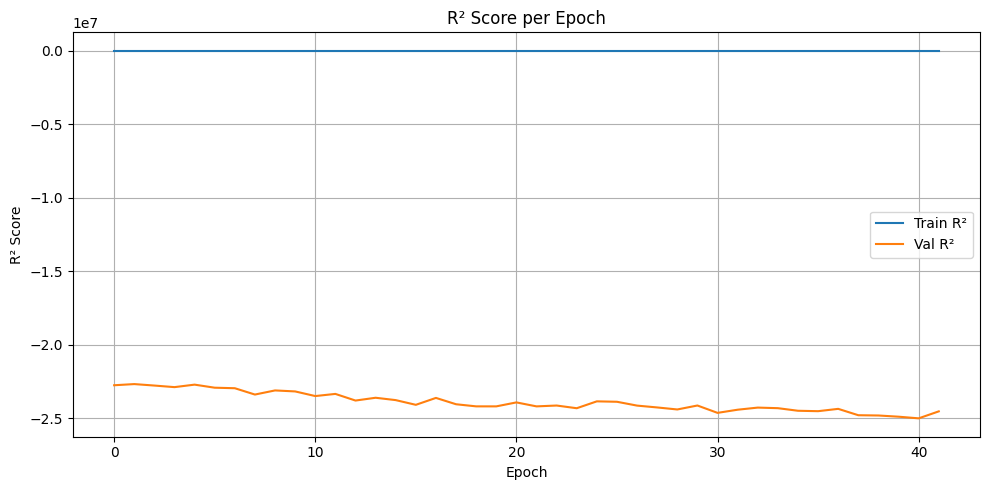

In [213]:
plt.figure(figsize=(10, 5))
plt.plot(history_dict['r2_score_per_timestep'], label='Train R²')
plt.plot(history_dict['val_r2_score_per_timestep'], label='Val R²')
plt.title("R² Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

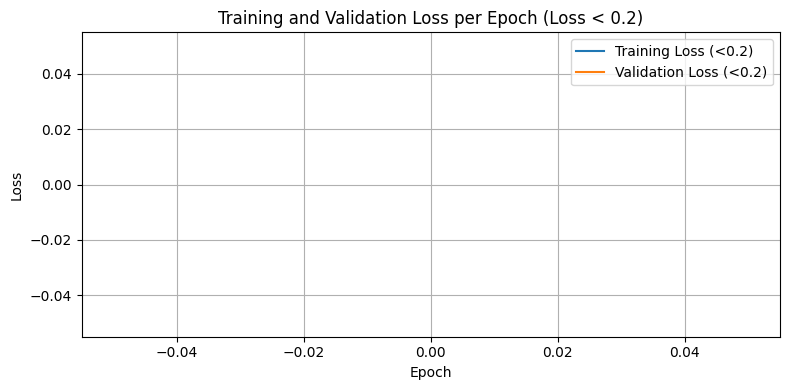

In [214]:
plt.figure(figsize=(8, 4))
train_loss = np.array(history_dict['loss'])
val_loss = np.array(history_dict['val_loss'])
epochs = np.arange(len(train_loss))

mask = train_loss < 0.05
plt.plot(epochs[mask], train_loss[mask], label='Training Loss (<0.2)')
plt.plot(epochs[mask], val_loss[mask], label='Validation Loss (<0.2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch (Loss < 0.2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



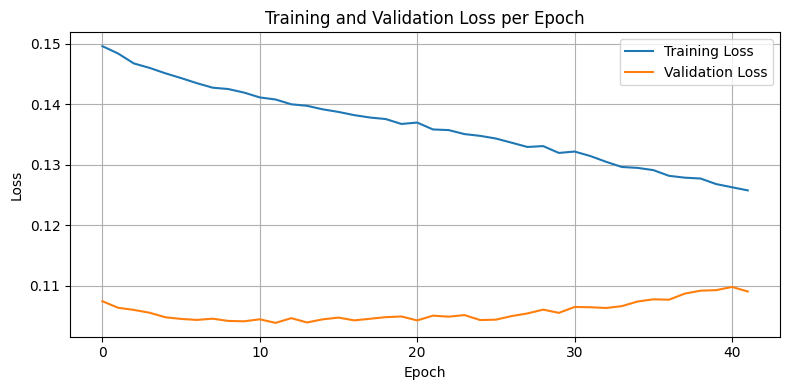

In [215]:
plt.figure(figsize=(8, 4))
train_loss = np.array(history_dict['loss'])
val_loss = np.array(history_dict['val_loss'])
epochs = np.arange(len(train_loss))

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [216]:
model.compile(
    optimizer=optimizer,
    loss=weighted_rmse_wrapper(species_weights),   # or your original loss
    metrics=[r2_score_per_timestep]  # include your custom metric if used
)

## Evaluate the model

In [217]:
loss = model.evaluate(
    {
        'seq_input': X_seq_test,
        'mch_input': X_static_test[:, 2].astype(np.float32),
        'species': X_static_test[:, 1].astype(np.int32),
        'year_input': X_static_test[:, 3].astype(np.int32),
        'day_sin': X_static_test[:, 4].astype(np.float32),
        'day_cos': X_static_test[:, 5].astype(np.float32),
        'site_longitude': X_static_test[:, 0].astype(np.float32),
        'site_latitude': X_static_test[:, 1].astype(np.float32),
        'tree_type': X_static_test[:, 7].astype(np.int32)
    },
    y_test_with_species
)
print("Test Loss:", loss)


277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1410 - r2_score_per_timestep: -26697336.0000
Test Loss: [0.13102616369724274, -34859848.0]


In [218]:
# Flatten the sequence input
sample_size = 10  # can adjust this
# Flatten seq_input (shape: n, seq_len, n_features) → (n, seq_len * n_features)
seq_flat = X_seq_test.reshape((X_seq_test.shape[0], -1))

# Concatenate with static features (site, species, mch)
X_shap = np.concatenate([seq_flat, X_static_test], axis=1).astype(np.float32)


In [219]:
def model_predict(data):
    n_seq_features = X_seq_test.shape[2]
    seq_len = X_seq_test.shape[1]
    
    seq_input = data[:, :seq_len * n_seq_features].reshape((-1, seq_len, n_seq_features))
    site_longitude_input = data[:, seq_len * n_seq_features].astype(np.int32).reshape(-1, 1)
    site_latitude_input = data[:, seq_len * n_seq_features + 1].astype(np.float32).reshape(-1, 1)
    species_input = data[:, seq_len * n_seq_features + 2].astype(np.int32).reshape(-1, 1)
    mch_input = data[:, seq_len * n_seq_features + 3].astype(np.float32).reshape(-1, 1)
    year_input = data[:, seq_len * n_seq_features + 4].astype(np.int32).reshape(-1, 1)
    day_sin_input = data[:, seq_len * n_seq_features + 5].astype(np.float32).reshape(-1, 1)
    day_cos_input = data[:, seq_len * n_seq_features + 6].astype(np.float32).reshape(-1, 1)
    tree_type_input = data[:, seq_len * n_seq_features + 7].astype(np.int32).reshape(-1, 1)

    # Return only the prediction for day 3, for example
    return model.predict({
        'seq_input': seq_input,
        'mch_input': mch_input,
        'site_longitude': site_longitude_input,
        'site_latitude': site_latitude_input,
        'species': species_input,
        'year_input': year_input,
        'day_sin': day_sin_input,
        'day_cos': day_cos_input,
        'tree_type': tree_type_input
    })[:, 0]  # Only the 1st day



In [228]:
print(X_shap.shape)
print(SEQ_LEN == X_seq_test.shape[1])
n_dyn = X_seq_test.shape[2]

dynamic_names = [f"{feat}_t{t}" for t in range(SEQ_LEN) for feat in dynamic_scaled_features]
#static_names = ['site_enc', 'species_enc', 'mch_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled']
static_names = ['site_longitude', 'site_latitude', 'species_enc', 'mch_scaled', 'year_enc', 'day_sin_scaled', 'day_cos_scaled', 'tree_type_enc']
feature_names = dynamic_names + static_names
print(feature_names)

(8840, 428)
True
['pr_rolling30_scaled_t0', 'at_rolling30_scaled_t0', 'ws_rolling30_scaled_t0', 'dp_rolling30_scaled_t0', 'sr_rolling30_scaled_t0', 'lr_rolling30_scaled_t0', 'twd_rolling30_log_scaled_t0', 'pr_rolling30_scaled_t1', 'at_rolling30_scaled_t1', 'ws_rolling30_scaled_t1', 'dp_rolling30_scaled_t1', 'sr_rolling30_scaled_t1', 'lr_rolling30_scaled_t1', 'twd_rolling30_log_scaled_t1', 'pr_rolling30_scaled_t2', 'at_rolling30_scaled_t2', 'ws_rolling30_scaled_t2', 'dp_rolling30_scaled_t2', 'sr_rolling30_scaled_t2', 'lr_rolling30_scaled_t2', 'twd_rolling30_log_scaled_t2', 'pr_rolling30_scaled_t3', 'at_rolling30_scaled_t3', 'ws_rolling30_scaled_t3', 'dp_rolling30_scaled_t3', 'sr_rolling30_scaled_t3', 'lr_rolling30_scaled_t3', 'twd_rolling30_log_scaled_t3', 'pr_rolling30_scaled_t4', 'at_rolling30_scaled_t4', 'ws_rolling30_scaled_t4', 'dp_rolling30_scaled_t4', 'sr_rolling30_scaled_t4', 'lr_rolling30_scaled_t4', 'twd_rolling30_log_scaled_t4', 'pr_rolling30_scaled_t5', 'at_rolling30_scaled_

 background = X_shap[:20]: A sample of representative input data used by SHAP to estimate the baseline prediction (i.e., what the model would predict in the absence of specific feature values. You're telling SHAP to use the first 20 samples from your input data as the background set for reference.

In [221]:
# background = X_shap[:20]
background = X_shap[np.random.choice(len(X_shap), 100, replace=False)]
explainer = shap.KernelExplainer(model_predict, background)
#shap_values = explainer.shap_values(X_shap[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step


In [222]:
feature_names

['pr_rolling30_scaled_t0',
 'at_rolling30_scaled_t0',
 'ws_rolling30_scaled_t0',
 'dp_rolling30_scaled_t0',
 'sr_rolling30_scaled_t0',
 'lr_rolling30_scaled_t0',
 'twd_rolling30_log_scaled_t0',
 'pr_rolling30_scaled_t1',
 'at_rolling30_scaled_t1',
 'ws_rolling30_scaled_t1',
 'dp_rolling30_scaled_t1',
 'sr_rolling30_scaled_t1',
 'lr_rolling30_scaled_t1',
 'twd_rolling30_log_scaled_t1',
 'pr_rolling30_scaled_t2',
 'at_rolling30_scaled_t2',
 'ws_rolling30_scaled_t2',
 'dp_rolling30_scaled_t2',
 'sr_rolling30_scaled_t2',
 'lr_rolling30_scaled_t2',
 'twd_rolling30_log_scaled_t2',
 'pr_rolling30_scaled_t3',
 'at_rolling30_scaled_t3',
 'ws_rolling30_scaled_t3',
 'dp_rolling30_scaled_t3',
 'sr_rolling30_scaled_t3',
 'lr_rolling30_scaled_t3',
 'twd_rolling30_log_scaled_t3',
 'pr_rolling30_scaled_t4',
 'at_rolling30_scaled_t4',
 'ws_rolling30_scaled_t4',
 'dp_rolling30_scaled_t4',
 'sr_rolling30_scaled_t4',
 'lr_rolling30_scaled_t4',
 'twd_rolling30_log_scaled_t4',
 'pr_rolling30_scaled_t5',
 'a

  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 118s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 114s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 121s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 121s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 119s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 117s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 116s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 119s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 118s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 121s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 120s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
9069/9069 ━━━━━━━━━━━━━━━━━━━━ 119s 1

C:\Users\salom\AppData\Local\Temp\ipykernel_35176\1645067214.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_subset, feature_names=feature_names)


IndexError: list index out of range

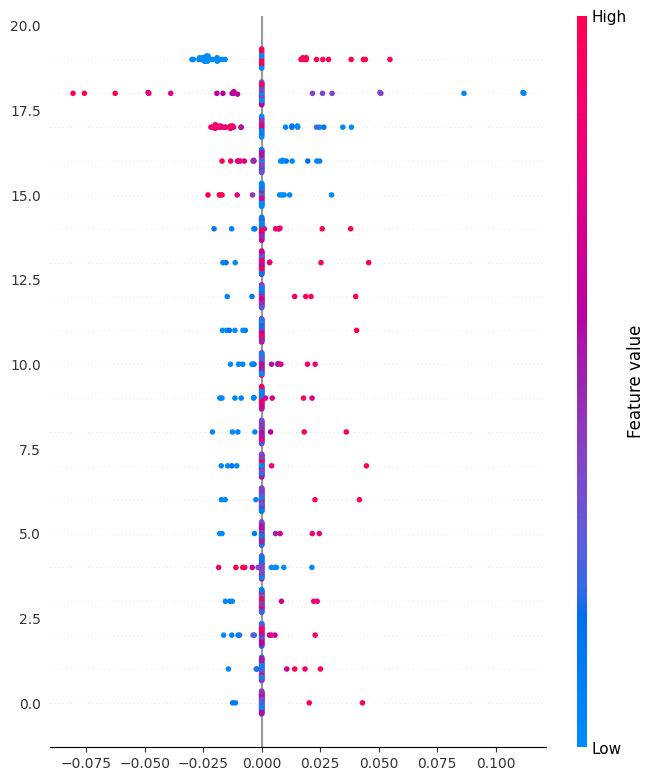

In [ ]:
# === Compute SHAP values ===
# If your model outputs 7 values (7-day forecast), specify ranked_outputs=1 to pick the most important one
# Make sure your input is shaped (samples, features), not (features, samples)
nb_samples_shap = 50

# Randomly select nb_samples_shap indices
indices = np.random.choice(len(X_shap), nb_samples_shap, replace=False)
X_shap_subset = X_shap[indices]


bool_run_shap = True
if bool_run_shap:
    # Compute SHAP values for the subset
    shap_values = explainer.shap_values(X_shap_subset)  # shape: (5, 183)



428
(50, 428)
(50, 428)


C:\Users\salom\AppData\Local\Temp\ipykernel_35176\3208643861.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_subset, feature_names=feature_names)


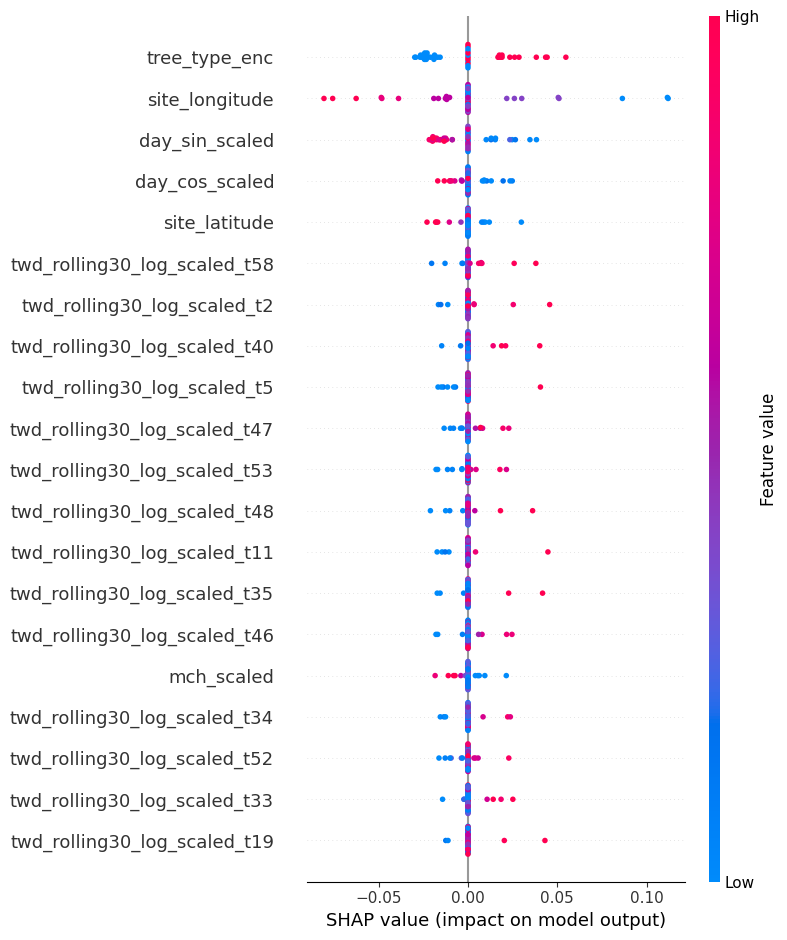

In [230]:
print(len(feature_names))
print(shap_values.shape)
print(shap_values.shape)
shap.summary_plot(shap_values, X_shap_subset, feature_names=feature_names)

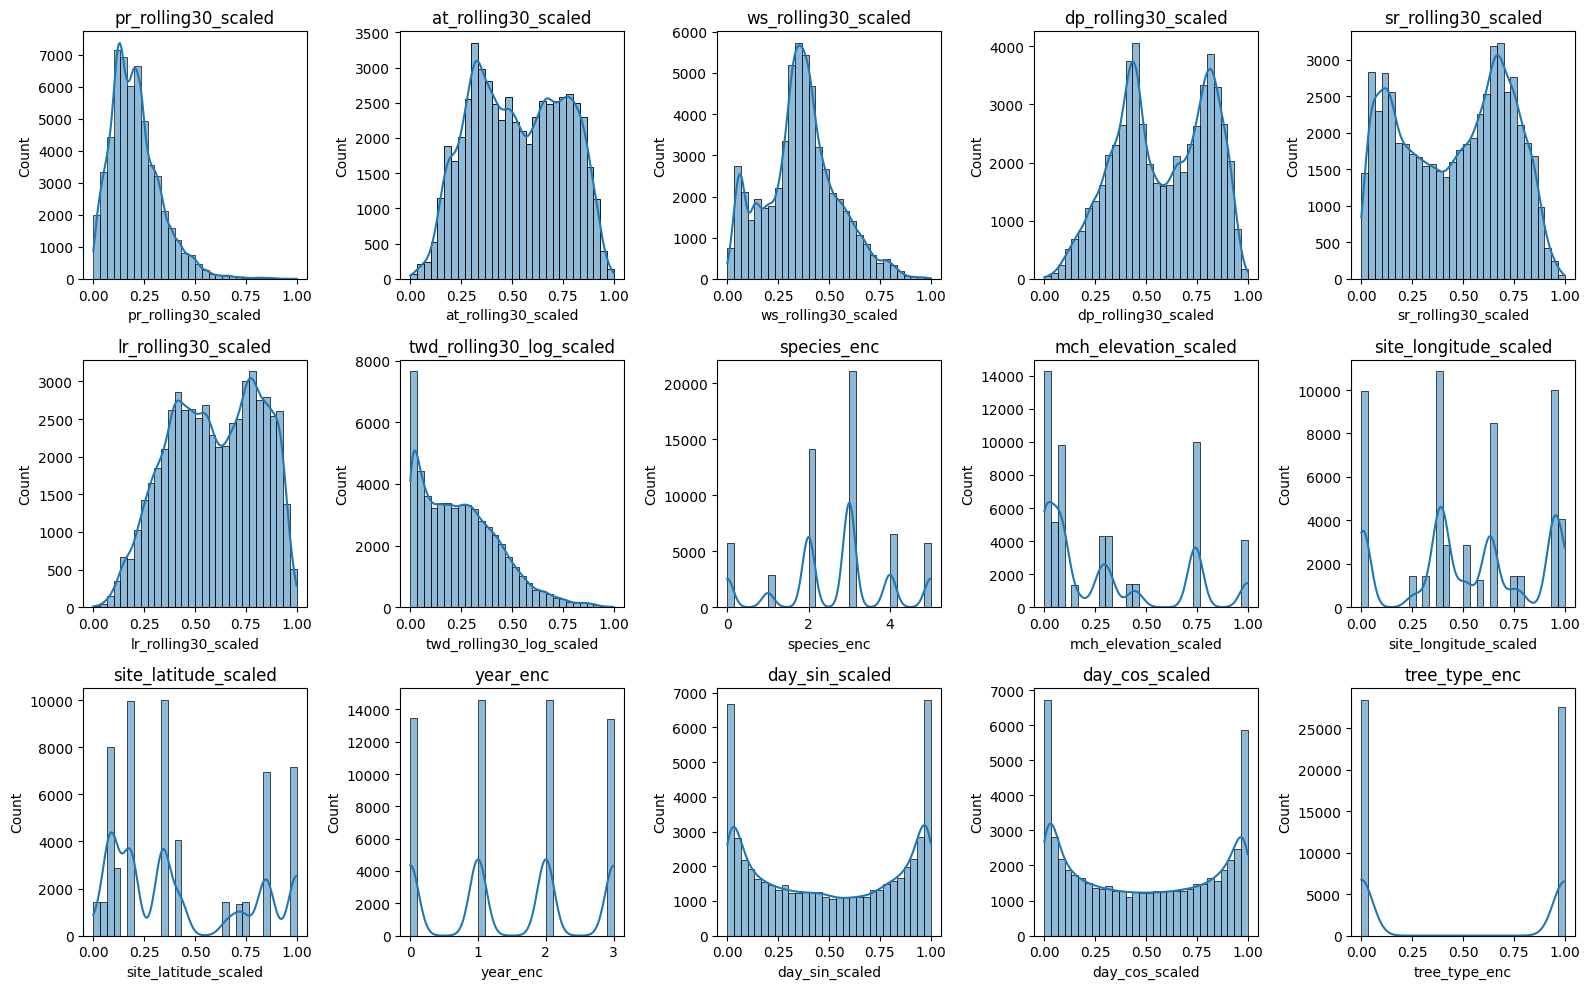

In [231]:
# Plot the distribution of each input variable (scaled dynamic and static features)
input_vars = dynamic_scaled_features + static_scaled_features
plt.figure(figsize=(16, 10))
for i, col in enumerate(input_vars):
    plt.subplot(3, int(np.ceil(len(input_vars)/3)), i+1)
    sns.histplot(df_ts_series[col], kde=True, bins=30)
    plt.title(col)
    plt.tight_layout()
plt.show()

In [232]:
feature_names

['pr_rolling30_scaled_t0',
 'at_rolling30_scaled_t0',
 'ws_rolling30_scaled_t0',
 'dp_rolling30_scaled_t0',
 'sr_rolling30_scaled_t0',
 'lr_rolling30_scaled_t0',
 'twd_rolling30_log_scaled_t0',
 'pr_rolling30_scaled_t1',
 'at_rolling30_scaled_t1',
 'ws_rolling30_scaled_t1',
 'dp_rolling30_scaled_t1',
 'sr_rolling30_scaled_t1',
 'lr_rolling30_scaled_t1',
 'twd_rolling30_log_scaled_t1',
 'pr_rolling30_scaled_t2',
 'at_rolling30_scaled_t2',
 'ws_rolling30_scaled_t2',
 'dp_rolling30_scaled_t2',
 'sr_rolling30_scaled_t2',
 'lr_rolling30_scaled_t2',
 'twd_rolling30_log_scaled_t2',
 'pr_rolling30_scaled_t3',
 'at_rolling30_scaled_t3',
 'ws_rolling30_scaled_t3',
 'dp_rolling30_scaled_t3',
 'sr_rolling30_scaled_t3',
 'lr_rolling30_scaled_t3',
 'twd_rolling30_log_scaled_t3',
 'pr_rolling30_scaled_t4',
 'at_rolling30_scaled_t4',
 'ws_rolling30_scaled_t4',
 'dp_rolling30_scaled_t4',
 'sr_rolling30_scaled_t4',
 'lr_rolling30_scaled_t4',
 'twd_rolling30_log_scaled_t4',
 'pr_rolling30_scaled_t5',
 'a

Unique site_enc in X_shap_subset: [0. 1. 2. 3. 4. 5.]
Corresponding site names: ['Bachtel-Forest' 'Bueren-Forest' 'Bursins-Forest' 'Choeliacher-Orchard'
 'Davos-Seehornwald' 'Genolier-Forest']
Site Enc Values: [2. 3. 3. 2. 0. 0. 4. 3. 2. 2. 2. 0. 0. 2. 0. 2. 2. 3. 3. 2. 4. 2. 3. 3.
 0. 5. 5. 3. 2. 3. 3. 5. 0. 3. 4. 1. 0. 0. 2. 2. 3. 2. 2. 3. 2. 3. 2. 4.
 5. 3.]


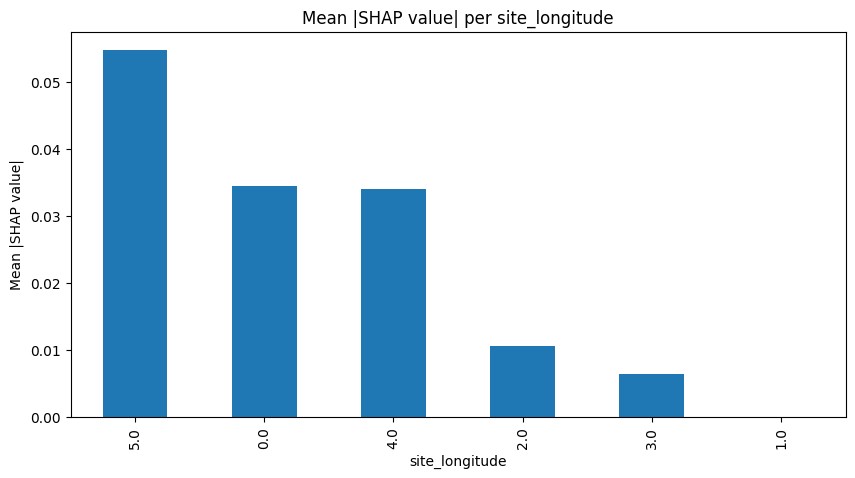

In [233]:
if bool_run_shap:

    site_enc_idx = feature_names.index('site_longitude')

    # Print unique values of site_enc in X_shap_subset
    print("Unique site_enc in X_shap_subset:", np.unique(X_shap_subset[:, site_enc_idx]))

    # To get the corresponding site names, map site_enc back to site using the label encoder
    unique_site_encs = np.unique(X_shap_subset[:, site_enc_idx]).astype(int)
    unique_sites = le_site.inverse_transform(unique_site_encs)
    print("Corresponding site names:", unique_sites)

    # Assume shap_values shape: (nb_samples_shap, n_features)
    # Find the index of 'site_enc' in your feature_names
    site_idx = feature_names.index('site_longitude')

    # Get the site_enc values for your SHAP sample
    site_enc_values = X_shap_subset[:, site_idx]
    print("Site Enc Values:", site_enc_values)
    site_shap = shap_values[:, site_idx]

    # Create a DataFrame for easy grouping
    df_site = pd.DataFrame({
        'site_longitude': site_enc_values,
        'shap': site_shap
    })

    # Calculate mean absolute SHAP value per site
    site_shap_mean = df_site.groupby('site_longitude')['shap'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    site_shap_mean.plot(kind='bar')
    plt.title('Mean |SHAP value| per site_longitude')
    plt.xlabel('site_longitude')
    plt.ylabel('Mean |SHAP value|')
    plt.show()

In [234]:
print("Unique site_enc in X_static_test:", np.unique(X_static_test[:, 0]))
print("Unique site_enc in X_shap:", np.unique(X_shap[:, site_idx]))

Unique site_enc in X_static_test: [np.int64(0) np.int64(1) np.int64(2) np.int64(3) np.int64(4) np.int64(5)]
Unique site_enc in X_shap: [0. 1. 2. 3. 4. 5.]


In [235]:
site_enc_values = X_shap[:nb_samples_shap, site_idx]
site_enc_values

array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
      dtype=float32)

In [236]:
print("First few target values:", y_train[:10, 0])
print(np.mean(y_train[:, 0]), np.std(y_train[:, 0]))

First few target values: [0.36320093 0.37255672 0.38179313 0.39123171 0.40440483 0.41681783
 0.43326751 0.44791379 0.46137328 0.47244372]
0.25303396446675513 0.1963846066753597


In [237]:
y_pred = model.predict({
    'seq_input': X_seq_test.astype(np.float32),
    'mch_input': X_static_test[:, 3].astype(np.float32).reshape(-1, 1),
    'site_longitude': X_static_test[:, 0].astype(np.int32).reshape(-1, 1),
    'site_latitude': X_static_test[:, 1].astype(np.float32).reshape(-1, 1),
    'species': X_static_test[:, 2].astype(np.int32).reshape(-1, 1),
    'year_input': X_static_test[:, 4].astype(np.int32).reshape(-1, 1),
    'day_sin': X_static_test[:, 5].astype(np.float32).reshape(-1, 1),
    'day_cos': X_static_test[:, 6].astype(np.float32).reshape(-1, 1),
    'tree_type': X_static_test[:, 7].astype(np.int32).reshape(-1, 1)
})
# Unscale predictions
y_pred_unscaled = scalers[target_column].inverse_transform(y_pred)
y_pred_original = np.expm1(y_pred_unscaled) #  Inverse log1p

277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [238]:
y_pred_original

array([[0.48916262],
       [0.47861332],
       [0.46875742],
       ...,
       [0.14205371],
       [0.14271957],
       [0.14325409]], dtype=float32)

In [242]:
y_test_unscaled = scalers[target_column].inverse_transform(y_test)
# Inverse log1p to get original units
y_test_original = np.expm1(y_test_unscaled)
y_test_original

array([[0.3983765 ],
       [0.3763637 ],
       [0.35742692],
       ...,
       [0.00766518],
       [0.01296132],
       [0.02055084]])

In [243]:
print("y_pred shape:", y_pred.shape) # Number of sequences
print("Total predicted values:", y_pred.shape[0] * y_pred.shape[1])

y_pred shape: (8840, 1)
Total predicted values: 8840


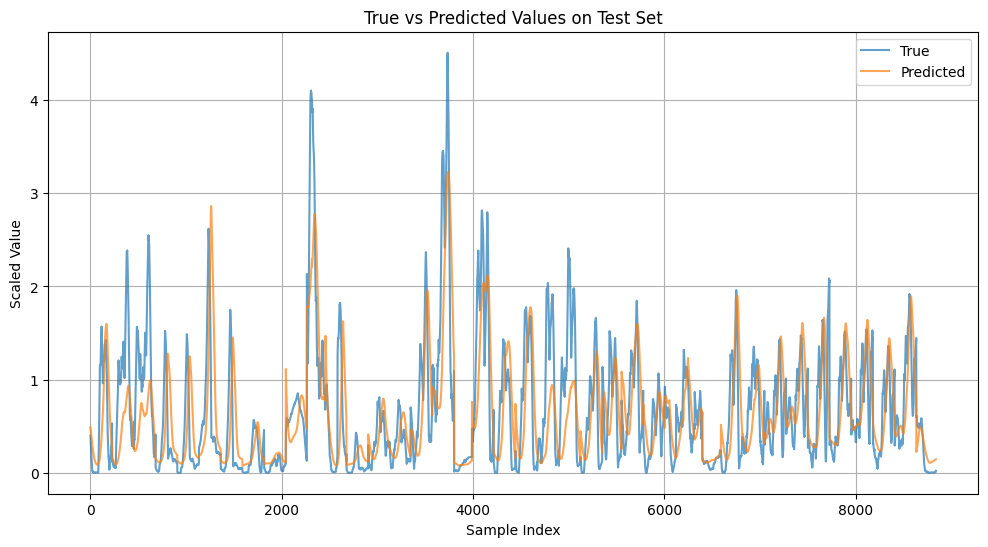

In [244]:
# Plot true vs predicted

plt.figure(figsize=(12, 6))
plt.plot(y_test_original[:, 0], label='True', alpha=0.7)
plt.plot(y_pred_original[:, 0], label='Predicted', alpha=0.7)
plt.title('True vs Predicted Values on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

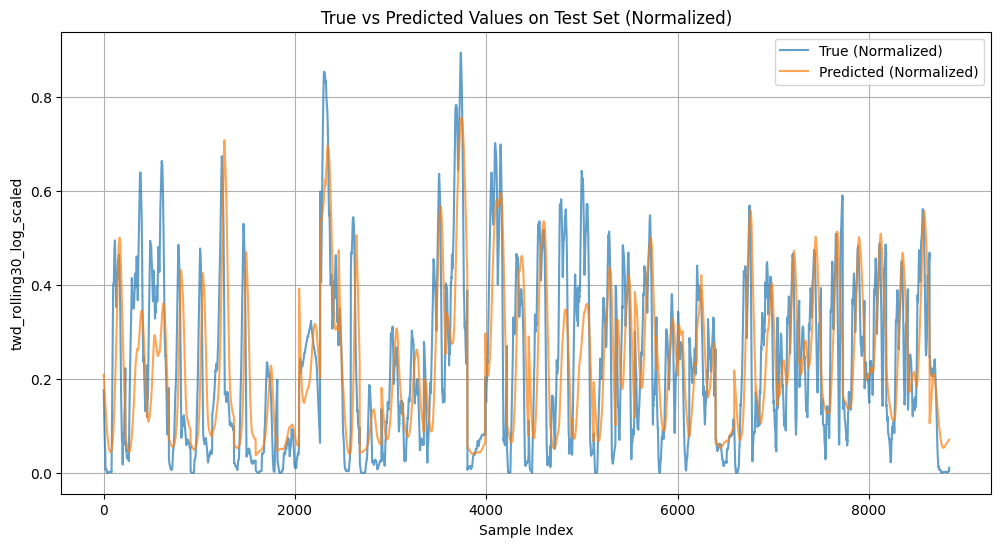

In [245]:
# Plot normalized values (twd_rolling30_log_scaled)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:, 0], label='True (Normalized)', alpha=0.7)
plt.plot(y_pred[:, 0], label='Predicted (Normalized)', alpha=0.7)
plt.title('True vs Predicted Values on Test Set (Normalized)')
plt.xlabel('Sample Index')
plt.ylabel('twd_rolling30_log_scaled')
plt.legend()
plt.grid(True)
plt.show()

In [250]:
species_names = le_species.inverse_transform(np.unique(X_static_test[:, 1].astype(int)))
species_codes = np.unique(X_static_test[:, 1].astype(int))

cum_days = df_test['cum.time.days'].iloc[SEQ_LEN:SEQ_LEN+len(y_test)].values
print(species_codes)
species_names


[0 1]


array(['Carpinus betulus', 'Corylus avellana'], dtype=object)

In [ ]:
for code, name in zip(species_codes, species_names):
    mask = X_static_test[:, 1].astype(int) == code
    plt.figure(figsize=(14, 6))
    plt.scatter(cum_days[mask], y_test_original[mask, 0], label='True', color='black', alpha=0.6, s=10)
    plt.scatter(cum_days[mask], y_pred_original[mask, 0], label='Predicted', color='orange', alpha=0.6, s=10)
    plt.xlabel('Cumulative Day')
    plt.ylabel('Tree Water Deficit')
    plt.title(f'True vs Predicted Values Over Time - {name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [247]:
y_test.shape

(8840, 1)